# Task 1 — Build a GPT-Style LLM From Scratch

**DATA266 Lab 1 · Member: `shreya` · Character-level GPT on TinyStories**

This notebook is self-contained and runs top-to-bottom. Everything it depends on comes from
`../config.yaml` — there are no hard-coded personal paths and no secrets.

| Spec section | Where it happens in this notebook |
|---|---|
| 1.1 Data preprocessing (5) | Steps 1–4 |
| 1.2 GPT model from scratch (15) | Steps 5–6 |
| 1.3 Training + generation (8) | Steps 7–10 |
| 1.4 Failure analysis (2) | Step 12 (evidence) → `../failure_analysis.md` (your words) |
| Metrics (all 13) | Step 11 → `../metrics_report.csv` |

**Hard constraint from the brief:** *no prebuilt Transformer or attention modules.*
`nn.MultiheadAttention`, `nn.Transformer*`, and `F.scaled_dot_product_attention` are never used.
Step 6 runs an automated assertion that proves this.

> Read `../PIPELINE_EXPLAINED.md` alongside this notebook — it explains *why* each piece is
> built the way it is, which is what the viva grades.


---
## Step -1 - Colab bootstrap

Skip this if you are running locally; the cell detects that and does nothing.

On Colab, set `GITHUB_REPO` (or put a copy of the repo in your Drive) and run it. It installs the
two packages Colab lacks, mounts Drive so checkpoints and logs survive the session, points
`LAB1_ROOT` at the repo, and fetches only as much of the corpus as `config.yaml` actually reads.

Data goes to local disk, not Drive: reading a multi-GB file over the Drive FUSE mount is very slow,
and re-fetching a 36 MB slice each session costs seconds. Code, checkpoints, logs and manifests all
stay on Drive.

**Caveat:** there is no mid-training resume. If the Colab session drops during training you re-run
from the start. Per-epoch checkpoints are written, and Step 8b can rebuild the reports from a run
that did finish, but training itself is not resumable. On free Colab consider fewer epochs or a
smaller model.


In [26]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# ---- edit these if you are on Colab -----------------------------------------
GITHUB_REPO = ""      # e.g. "https://github.com/<team>/<repo>.git"; blank = use a copy in Drive
USE_DRIVE   = True    # False keeps everything in /content and loses it when the session ends
# -----------------------------------------------------------------------------

if not IN_COLAB:
    print("not on Colab - nothing to do")
else:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "datasets", "huggingface_hub", "pyyaml"], check=False)

    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        base = Path("/content/drive/MyDrive/DATA266_Lab1")
    else:
        base = Path("/content/DATA266_Lab1")
        print("NOT using Drive - checkpoints, logs and manifests die with this session")
    base.mkdir(parents=True, exist_ok=True)

    root = base / ""
    if GITHUB_REPO and not root.exists():
        subprocess.run(["git", "clone", GITHUB_REPO, str(root)], check=True)
    if not (root / "task1_llm").is_dir():
        raise RuntimeError(f"{root} is not the repo. Set GITHUB_REPO above, "
                           f"or copy the repo folder into {base}.")

    data_dir = Path("/content/lab1_data/task1")
    data_dir.mkdir(parents=True, exist_ok=True)

    os.environ["LAB1_ROOT"] = str(root)
    os.environ["LAB1_DATA"] = str(data_dir)
    os.chdir(root / "task1_llm" / "shreya_akotiya" / "src")

    # # Only download what this config reads: offset + use_chars (+5% slack for
    # # story-boundary snapping). --stream stops early instead of pulling all 1.9 GB.
    # import yaml
    # cfg = yaml.safe_load(open(root / "task1_llm" / "shreya_akotiya" / "config.yaml"))
    # raw = data_dir / cfg["data"]["raw_filename"]
    # need = int((cfg["data"]["member_offset_chars"] + cfg["data"]["use_chars"]) * 1.05)
    # if not raw.exists() or raw.stat().st_size < need:
    #     subprocess.run([sys.executable, str(root / "task1_llm" / "shreya_akotiya" / "src" / "fetch_data.py"),
    #                     "--chars", str(need), "--stream"], check=True)

    gpu = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                         capture_output=True, text=True).stdout.strip()
    print(f"LAB1_ROOT = {root}")
    print(f"LAB1_DATA = {data_dir}")
    print(f"GPU       = {gpu or 'none - CPU runtime, this will be slow'}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LAB1_ROOT = /content/drive/MyDrive/DATA266_Lab1
LAB1_DATA = /content/lab1_data/task1
GPU       = Tesla T4, 15360 MiB


---
## Step 0 — Environment, paths, config, logging

Three things get set up here, in this order:

1. **Paths** are discovered by walking up from the notebook until a folder containing
   `task1_llm/` is found. That keeps the notebook portable (local Mac, Colab, GPU lab) without
   anyone editing a path string.
2. **Config** is read from `../config.yaml`. Nothing below invents a hyperparameter.
3. **Raw log** — a timestamped, append-only log file in `reproducibility/raw_logs/`.
   The brief says this file is the *evidence trail*: never edit or tidy it after a run.


In [27]:
import os, sys, json, math, time, random, logging, platform, hashlib, resource, subprocess, textwrap
from pathlib import Path
from collections import Counter
from datetime import datetime
from typing import Optional   # not `X | None`: that syntax needs Python 3.10+

import numpy as np
import pandas as pd
import yaml
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

matplotlib.rcParams["figure.dpi"] = 120


# ---- paths -------------------------------------------------------------------
def find_project_root(start: Optional[Path] = None) -> Path:
    """Walk upward until we hit the repo root (the folder that contains task1_llm/)."""
    here = Path(start or Path.cwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "task1_llm").is_dir():
            return cand
    raise RuntimeError(
        "Could not locate the repo root. Set the LAB1_ROOT environment variable "
        "to the folder that contains task1_llm/ (useful on Colab)."
    )

PROJECT_ROOT = Path(os.environ["LAB1_ROOT"]).resolve() if os.environ.get("LAB1_ROOT") else find_project_root()

MEMBER         = "shreya_akotiya"
TASK_DIR       = PROJECT_ROOT / "task1_llm"
# LAB1_DATA lets Colab keep the corpus on local disk instead of Drive (FUSE is slow).
SHARED_DATA    = (Path(os.environ["LAB1_DATA"]) if os.environ.get("LAB1_DATA")
                  else TASK_DIR / "data")   # shared raw TinyStories (team-level)
MEMBER_DIR     = TASK_DIR / MEMBER
SRC_DIR        = MEMBER_DIR / "src"
REPRO_DIR      = PROJECT_ROOT / "reproducibility"
LOG_DIR        = REPRO_DIR / "raw_logs" / MEMBER / "task1_llm"
MANIFEST_DIR   = REPRO_DIR / "manifests" / MEMBER


# ---- config ------------------------------------------------------------------
# LAB1_CONFIG lets a smoke test point at a smaller config without touching the real one.
CONFIG_PATH = Path(os.environ.get("LAB1_CONFIG") or (MEMBER_DIR / "config.yaml"))
with open(CONFIG_PATH) as f:
    CFG = yaml.safe_load(f)

RUN_ID   = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = CFG["run"]["run_name"]
RUN_TAG  = f"task1_{MEMBER}_{RUN_NAME}_{RUN_ID}"

# --- artifact isolation --------------------------------------------------------
# Derived artifacts (metrics_report.csv, plots, samples, history) have FIXED names,
# because that is what the brief asks a grader to find. That makes them easy to
# clobber: a 30-second smoke run with a smaller config will silently overwrite the
# reports from a 60-minute real run, and the run tag lives only in the log and
# checkpoint filenames, so nothing warns you.
# A run writes to the canonical paths only if run.reported is true AND run_name does
# not look like a throwaway. Anything else is sandboxed under
# outputs/_scratch_<run_name>/ so it cannot clobber a real run's reports.
# Two independent guards, because losing a 60-minute run's reports to a 30-second
# test is exactly the kind of mistake that only shows up once it has happened.
_SCRATCH_WORDS = ("smoke", "debug", "test", "scratch", "tmp")
IS_SCRATCH = (not bool(CFG["run"].get("reported", True))
              or any(w in RUN_NAME.lower() for w in _SCRATCH_WORDS))

if IS_SCRATCH:
    _root          = MEMBER_DIR / "outputs" / f"_scratch_{RUN_NAME}"
    OUT_DIR        = _root
    DATA_PROCESSED = _root / "data_processed"
    CKPT_DIR       = _root / "checkpoints"
    METRICS_PATH   = _root / "metrics_report.csv"
    REQS_PATH      = _root / "requirements.txt"
else:
    OUT_DIR        = MEMBER_DIR / "outputs"
    DATA_PROCESSED = MEMBER_DIR / "data_processed"
    CKPT_DIR       = MEMBER_DIR / "checkpoints"
    METRICS_PATH   = MEMBER_DIR / "metrics_report.csv"
    REQS_PATH      = MEMBER_DIR / "requirements.txt"

PLOT_DIR   = OUT_DIR / "plots"
SAMPLE_DIR = OUT_DIR / "samples"

for d in (SHARED_DATA, DATA_PROCESSED, CKPT_DIR, OUT_DIR, PLOT_DIR, SAMPLE_DIR,
          LOG_DIR, MANIFEST_DIR):
    d.mkdir(parents=True, exist_ok=True)


# ---- raw log -----------------------------------------------------------------
LOG_PATH = LOG_DIR / f"{RUN_TAG}.log"
logger = logging.getLogger("task1")
logger.handlers.clear()                # re-running this cell must not duplicate handlers
logger.setLevel(logging.INFO)
logger.propagate = False
_fmt = logging.Formatter("%(asctime)s | %(levelname)-5s | %(message)s", "%Y-%m-%d %H:%M:%S")
_fh = logging.FileHandler(LOG_PATH); _fh.setFormatter(_fmt); logger.addHandler(_fh)
_sh = logging.StreamHandler(sys.stdout); _sh.setFormatter(_fmt); logger.addHandler(_sh)
log = logger.info


# ---- determinism -------------------------------------------------------------
SEED = int(CFG["run"]["seed"])
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ---- device ------------------------------------------------------------------
def pick_device(pref: str) -> torch.device:
    if pref != "auto":
        return torch.device(pref)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = pick_device(CFG["run"]["device"])

HARDWARE = {
    "device": str(DEVICE),
    "platform": platform.platform(),
    "processor": platform.processor() or platform.machine(),
    "python": platform.python_version(),
    "torch": torch.__version__,
    "numpy": np.__version__,
}
if DEVICE.type == "cuda":
    HARDWARE["gpu_name"] = torch.cuda.get_device_name(0)
    HARDWARE["gpu_total_mem_gb"] = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)
elif DEVICE.type == "mps":
    try:
        HARDWARE["cpu_brand"] = subprocess.check_output(
            ["sysctl", "-n", "machdep.cpu.brand_string"], text=True).strip()
        HARDWARE["system_mem_gb"] = round(
            int(subprocess.check_output(["sysctl", "-n", "hw.memsize"], text=True)) / 1e9, 2)
    except Exception:
        pass

if IS_SCRATCH:
    log(f"*** SCRATCH RUN (run_name='{RUN_NAME}') - artifacts go to "
        f"{OUT_DIR.relative_to(PROJECT_ROOT)}; canonical reports are NOT touched ***")
else:
    log(f"*** REPORTED RUN (run_name='{RUN_NAME}') - writes the canonical "
        f"metrics_report.csv / outputs / checkpoints ***")
log(f"RUN_TAG      = {RUN_TAG}")
log(f"PROJECT_ROOT = {PROJECT_ROOT}")
log(f"CONFIG_PATH  = {CONFIG_PATH}")
log(f"RAW LOG      = {LOG_PATH.relative_to(PROJECT_ROOT)}")
log(f"HARDWARE     = {json.dumps(HARDWARE)}")
log(f"CONFIG       = {json.dumps(CFG)}")


2026-09-20 19:40:02 | INFO  | *** REPORTED RUN (run_name='deep_narrow') - writes the canonical metrics_report.csv / outputs / checkpoints ***
2026-09-20 19:40:02 | INFO  | RUN_TAG      = task1_shreya_deep_narrow_20260920_194002
2026-09-20 19:40:02 | INFO  | PROJECT_ROOT = /content/drive/MyDrive/DATA266_Lab1
2026-09-20 19:40:02 | INFO  | CONFIG_PATH  = /content/drive/MyDrive/DATA266_Lab1/task1_llm/shreya/config.yaml
2026-09-20 19:40:02 | INFO  | RAW LOG      = reproducibility/raw_logs/task1_shreya_deep_narrow_20260920_194002.log
2026-09-20 19:40:02 | INFO  | HARDWARE     = {"device": "cuda", "platform": "Linux-6.6.122+-x86_64-with-glibc2.39", "processor": "x86_64", "python": "3.13.15", "torch": "2.11.0+cu128", "numpy": "2.1.3", "gpu_name": "Tesla T4", "gpu_total_mem_gb": 15.64}
2026-09-20 19:40:02 | INFO  | CONFIG       = {"run": {"member": "shreya", "run_name": "deep_narrow", "reported": true, "seed": 1337, "device": "auto"}, "data": {"raw_filename": "tinystories_raw.txt", "story_separ

---
## Step 1 — Load this run's slice of the shared TinyStories corpus  *(spec 1.1.1)*

TinyStories is ~2.1 M short synthetic stories written with the vocabulary of a 3–4 year old.
That is exactly why the paper uses it: a *tiny* model can actually learn fluent English on it,
which would be impossible on web-scale text at this parameter count.

The raw corpus is a **team asset**, downloaded once by `task1_llm/fetch_data.py` into the shared
`task1_llm/data/` folder so every member starts from a byte-identical file. Stories in it are
separated by a blank line — that blank line *is* the end-of-story signal the character model has
to learn. We deliberately do not use a special `<|endoftext|>` marker, because at character level
that string would be spelled out one character at a time.

**Disk size and run size are separate concerns.** The pool on disk is ~1.9 GB; this run consumes
`data.use_chars` characters starting at `data.member_offset_chars`, so:

* the split is defined by config, not by however much happened to get downloaded, and
* each team member can point at a **different offset** and train on a genuinely disjoint slice
  of the same shared download (spec 1.1.4: *"each member creates their own split"*).

We seek to the byte offset, read a bounded slice, and then snap both ends to story boundaries so
no run ever begins or ends mid-story.


In [28]:
RAW_TXT    = SHARED_DATA / CFG["data"]["raw_filename"]
STORY_SEP  = CFG["data"]["story_separator"]
USE_CHARS  = int(CFG["data"]["use_chars"])
OFFSET     = int(CFG["data"]["member_offset_chars"])

if not RAW_TXT.exists():
    raise FileNotFoundError(
        f"Shared corpus not found: {RAW_TXT}\n\n"
        f"Download it once for the whole team:\n"
        f"    python {(MEMBER_DIR / 'src' / 'fetch_data.py')}\n"
    )


def read_slice(path: Path, offset: int, n_chars: int, sep: str) -> str:
    """Read ~n_chars from `offset`, then trim both ends to story boundaries.

    Seeking by byte can land mid-UTF-8-codepoint and mid-story; both are fixed by
    decoding with errors='ignore' and snapping to the nearest separator inward.
    A 1% slack margin covers the characters lost to that snapping.
    """
    slack = max(4096, int(n_chars * 0.01))
    with open(path, "rb") as f:
        f.seek(offset)
        blob = f.read(n_chars + 2 * slack)          # bytes ~= chars (corpus is ~99.9% ASCII)
    text = blob.decode("utf-8", errors="ignore")

    if offset > 0:                                   # drop the partial story we landed inside
        i = text.find(sep)
        text = text[i + len(sep):] if i != -1 else text
    text = text[:n_chars]
    j = text.rfind(sep)                              # drop the partial story at the tail
    if j != -1:
        text = text[:j + len(sep)]
    return text


file_chars = RAW_TXT.stat().st_size
if OFFSET + USE_CHARS > file_chars:
    raise RuntimeError(
        f"Slice [{OFFSET:,} : {OFFSET+USE_CHARS:,}] runs past the end of the corpus "
        f"({file_chars:,} chars). Lower data.use_chars / data.member_offset_chars, "
        f"or re-run fetch_data.py without a --chars cap."
    )

t0 = time.time()
raw_text = read_slice(RAW_TXT, OFFSET, USE_CHARS, STORY_SEP)
log(f"[data] pool on disk: {file_chars/1e9:.2f} GB")
log(f"[data] this run uses chars [{OFFSET:,} : {OFFSET+len(raw_text):,}] "
    f"= {len(raw_text):,} chars ({len(raw_text)/file_chars*100:.2f}% of the pool) "
    f"in {time.time()-t0:.1f}s")

assert raw_text.endswith(STORY_SEP), "slice should end on a story boundary"
print("\n--- first 600 characters of this run's slice ----------------------------\n")
print(raw_text[:600])


2026-09-20 19:40:02 | INFO  | [data] pool on disk: 0.04 GB
2026-09-20 19:40:02 | INFO  | [data] this run uses chars [0 : 33,999,907] = 33,999,907 chars (95.11% of the pool) in 0.2s

--- first 600 characters of this run's slice ----------------------------

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for shari


---
## Step 2 — Story-level train/validation split  *(spec 1.1.4)*

**Order matters here, and it is the single easiest place to silently cheat.**

We split **before** building the vocabulary and **before** cutting sequences:

```
raw stories ──split 90/10 by STORY──▶ train stories ──▶ vocab ──▶ train token stream
                                  └─▶ val   stories ──▶        ──▶ val   token stream
```

Why split on *stories* and not on characters or on shuffled sequences:

* If you shuffled sequences first, the tail of a story could land in train while its head lands
  in validation. The model would be scored on continuing text it has literally memorised, and
  your validation loss would look great for the wrong reason.
* The vocabulary is built from **train only**. Otherwise a character that appears exclusively in
  validation would get its own embedding — a small but real leak of test information into the
  model's parameters.

The split is a clean cut at a story boundary (last 10% of stories held out), not a random
shuffle, so it is trivially reproducible without storing an index list.


In [29]:
VAL_FRAC = float(CFG["data"]["val_story_fraction"])

stories = [s for s in raw_text.split(STORY_SEP) if s.strip()]
n_val_stories = max(1, int(len(stories) * VAL_FRAC))
train_stories = stories[:-n_val_stories]
val_stories   = stories[-n_val_stories:]

train_text_raw = STORY_SEP.join(train_stories) + STORY_SEP
val_text_raw   = STORY_SEP.join(val_stories) + STORY_SEP

log(f"[split] {len(stories):,} stories -> train {len(train_stories):,} | val {len(val_stories):,}")
log(f"[split] chars      -> train {len(train_text_raw):,} | val {len(val_text_raw):,}")

# Sanity: the two halves must not share a story.
assert set(train_stories[-3:]).isdisjoint(set(val_stories)), "train/val story overlap!"


2026-09-20 19:40:03 | INFO  | [split] 197,250 stories -> train 177,525 | val 19,725
2026-09-20 19:40:03 | INFO  | [split] chars      -> train 30,567,642 | val 3,432,263


---
## Step 3 — Character vocabulary  *(spec 1.1.1 & 1.1.3)*

A **character-level** tokenizer: one integer per character. No BPE, no word pieces, no
pretrained tokenizer. The two dictionaries the spec asks for by name are built here:

* `char_to_idx : str -> int`
* `idx_to_char : int -> str`

Three design decisions, all driven by what is actually in the corpus. Run
`python task1_llm/fetch_data.py --inspect-only` to reproduce the evidence.

**1. Unicode normalisation.** The corpus contains 35 distinct non-ASCII characters. Almost all
are typographic variants of ASCII ones: `RDQUO` (41,270), `LDQUO` (41,228), `RSQUO` (29,951),
en/em dashes, ellipsis, plus thin and zero-width spaces. Left alone, the model has to learn the
curly apostrophe and the straight one as unrelated symbols from wildly different amounts of data.
We fold them to ASCII first. After folding, only four non-ASCII characters survive (12
occurrences total) and they fall through to `<unk>`.

**2. A frequency floor alone is not safe.** Measured on this run's 30.7M-character training slice:

```
digits   0:97   1:97   2:40   3:677   4:19   5:38   6:5   7:8   8:13   9:11
letters  Q:146  X:27
```

A floor of 200 keeps `3` (it appears in "3 years old") while sending `4`, `6`, `7`, `9` to
`<unk>` — and it **deletes `Q` and `X` from the alphabet**. A model that can never write "Queen"
is not a defensible design.

**3. So the vocabulary is `{freq >= min_char_freq}` UNION `CORE`,** where `CORE` is the 73
printable ASCII characters a children's story actually needs: `A-Z`, `a-z`, `0-9`, space,
newline, and `. , ! ? ' " - : ;`. This has a second benefit that matters for the *team* score:
the vocabulary no longer depends on which slice of the corpus you read, so every member gets
**the same vocab size**, and perplexity / bits-per-character are directly comparable across
members. With a frequency-only vocabulary they would not be.

Result: **74 symbols** (73 core + `<unk>`). The 11 stray symbols that fall to `<unk>` account for
39 occurrences in 30.7M characters — 0.00013%.

`<unk>` sits at index 0 and decodes to the replacement character, so if the model ever emits one
it is immediately visible in the samples instead of silently rendering as something plausible.

Vocab size under 256 is what lets us store the token stream as `uint8` — 1 byte per token instead
of 8. The cell asserts this rather than assuming it.


In [30]:
import string

NORMALIZE  = bool(CFG["data"]["normalize_unicode"])
MIN_FREQ   = int(CFG["data"]["min_char_freq"])
FORCE_CORE = bool(CFG["data"]["force_core_vocab"])

# Every non-ASCII character observed in the corpus that has a sensible ASCII form.
# Built from the actual inventory printed by fetch_data.py --inspect-only.
UNICODE_FOLD = {
    # quotes
    "\u2018": "'", "\u2019": "'", "\u201a": "'", "\u201b": "'", "\u00b4": "'",
    "\u201c": '"', "\u201d": '"', "\u201e": '"',
    # dashes
    "\u2013": "-", "\u2014": "-", "\u2015": "-", "\u2212": "-",
    # spaces: thin, hair, four-per-em, non-breaking, zero-width, BOM, soft hyphen, tab
    "\u2009": " ", "\u200a": " ", "\u2005": " ", "\u00a0": " ",
    "\u200b": "",  "\ufeff": "",  "\u00ad": "",  "\t": " ",
    # line separator
    "\u2028": "\n", "\r\n": "\n", "\r": "\n",
    # misc
    "\u2026": "...", "\ufb01": "fi",
    # accented Latin -> base letter (names like "Jose", "Renee")
    "\u00e1": "a", "\u00e0": "a", "\u00e2": "a", "\u00e4": "a", "\u00e3": "a", "\u00c2": "A",
    "\u00e9": "e", "\u00e8": "e", "\u00ea": "e", "\u00eb": "e", "\u00c9": "E",
    "\u00ed": "i", "\u00ec": "i", "\u00ee": "i", "\u00ef": "i",
    "\u00f3": "o", "\u00f2": "o", "\u00f4": "o", "\u00f6": "o", "\u00f5": "o",
    "\u00fa": "u", "\u00f9": "u", "\u00fb": "u", "\u00fc": "u",
    "\u00f1": "n", "\u00e7": "c",
}

def normalize(text: str) -> str:
    if not NORMALIZE:
        return text
    for bad, good in UNICODE_FOLD.items():
        text = text.replace(bad, good)
    return text

train_text = normalize(train_text_raw)
val_text   = normalize(val_text_raw)

# --- build vocab from TRAIN ONLY ------------------------------------------------
CORE_VOCAB = set(string.ascii_letters + string.digits + " \n.,!?\'\"-:;")

counts   = Counter(train_text)
UNK      = "\ufffd"                                  # the replacement character
frequent = {ch for ch, n in counts.items() if n >= MIN_FREQ}
kept_set = (frequent | CORE_VOCAB) if FORCE_CORE else frequent

itos        = [UNK] + sorted(kept_set)               # index 0 is reserved for <unk>
char_to_idx = {ch: i for i, ch in enumerate(itos)}
idx_to_char = {i: ch for i, ch in enumerate(itos)}
VOCAB_SIZE  = len(itos)
UNK_ID      = 0

assert VOCAB_SIZE < 256, f"vocab {VOCAB_SIZE} >= 256 breaks the uint8 storage assumption"
if FORCE_CORE:
    assert CORE_VOCAB <= kept_set, "core vocabulary incomplete"

dropped   = {ch: n for ch, n in counts.items() if ch not in kept_set}
unk_chars = sum(dropped.values())
rescued   = sorted(CORE_VOCAB - frequent)            # kept only because of the core set

log(f"[vocab] size={VOCAB_SIZE} | floor={MIN_FREQ} | force_core={FORCE_CORE}")
log(f"[vocab] -> <unk>: {len(dropped)} distinct chars, {unk_chars} occurrences "
    f"({unk_chars/len(train_text)*100:.6f}% of training text)")
log(f"[vocab] rescued by the core set (below the floor but kept): {rescued}")

print("vocab:", "".join(repr(c)[1:-1] for c in itos))
print("\n10 most common:", counts.most_common(10))
print("dropped -> <unk>:", sorted(dropped.items(), key=lambda kv: -kv[1]))

with open(DATA_PROCESSED / "vocab.json", "w") as f:
    json.dump({"itos": itos, "char_to_idx": char_to_idx,
               "vocab_size": VOCAB_SIZE, "unk_id": UNK_ID,
               "min_char_freq": MIN_FREQ, "force_core_vocab": FORCE_CORE,
               "normalized": NORMALIZE,
               "unk_char_occurrences": unk_chars,
               "dropped_chars": sorted(dropped)}, f, indent=2)


2026-09-20 19:40:05 | INFO  | [vocab] size=78 | floor=50 | force_core=True
2026-09-20 19:40:05 | INFO  | [vocab] -> <unk>: 16 distinct chars, 93 occurrences (0.000304% of training text)
2026-09-20 19:40:05 | INFO  | [vocab] rescued by the core set (below the floor but kept): ['2', '4', '5', '6', '7', '8', '9', 'X']
vocab: �\n !"',-.0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyzœ˜€™

10 most common: [(' ', 5822152), ('e', 2897981), ('a', 2060887), ('t', 1905848), ('o', 1590985), ('h', 1496423), ('n', 1423309), ('i', 1312847), ('d', 1304703), ('s', 1257394)]
dropped -> <unk>: [('¦', 19), ('Ã', 19), ('©', 13), ('/', 7), ('$', 6), ('«', 5), ('»', 5), ('±', 4), ('*', 4), ('¡', 2), ('&', 2), ('(', 2), (')', 2), ('³', 1), ('+', 1), ('‰', 1)]


### Encode / decode

`encode` uses `str.translate` with a dict that falls back to `<unk>`: every kept character is
mapped to the *character whose code point equals its token id*, so the translated string encoded
as Latin-1 **is** the byte array of token ids. That turns a 30 M-iteration Python loop into one C
call. The cell below asserts it matches the obvious loop implementation, and that
`decode(encode(x)) == x`.


In [31]:
class _FallbackTable(dict):
    """str.translate lookup table that maps anything unseen to <unk>."""
    def __missing__(self, codepoint):
        return UNK_ID

_ENC_TABLE = _FallbackTable({ord(ch): idx for ch, idx in char_to_idx.items()})

def encode(text: str) -> np.ndarray:
    """str -> np.uint8 array of token ids."""
    return np.frombuffer(text.translate(_ENC_TABLE).encode("latin-1"), dtype=np.uint8)

def decode(ids) -> str:
    """iterable of ids -> str."""
    return "".join(idx_to_char[int(i)] for i in ids)


# --- correctness checks --------------------------------------------------------
_probe = train_text[:20_000] + "Ω emoji 🙂 test"          # includes out-of-vocab chars
_naive = np.array([char_to_idx.get(c, UNK_ID) for c in _probe], dtype=np.uint8)
assert np.array_equal(encode(_probe), _naive), "fast encode disagrees with naive encode"
assert decode(encode("Once upon a time, Lily saw a big red ball.")) == \
       "Once upon a time, Lily saw a big red ball.", "round-trip failed"
print("encode/decode checks passed")
print("encode('Hi!') ->", encode("Hi!"), "-> decode ->", repr(decode(encode("Hi!"))))


encode/decode checks passed
encode('Hi!') -> [29 56  3] -> decode -> 'Hi!'


---
## Step 4 — Fixed-length input→target sequences  *(spec 1.1.2)*

Autoregressive language modelling is next-token prediction, so a training example is a window of
text paired with **the same window shifted right by one**:

```
stream : O  n  c  e     u  p  o  n
x      : O  n  c  e     u  p  o        (positions 0..T-1)
y      :    n  c  e     u  p  o  n     (positions 1..T)
```

One window of length `T` therefore gives the model **T supervised predictions**, not one — every
position predicts its own next character, all in a single forward pass. That only works because
of causal masking (Step 5): position `i` is allowed to see `x[0..i]` and nothing after.

Config settings and what they mean:

* `seq_len = 256` — the context window. Measured story lengths in this corpus are p25 669 /
  median 784 / p75 956 characters, so a 256-character window is roughly **one third of a median
  story** — enough for real narrative context (a character introduced at the start is still
  visible), but far from a whole story. Attention cost is O(T²), so doubling T roughly quadruples
  the attention compute; on the MPS benchmark that is the difference between a 45-minute run and
  a 3-hour one.
* `stride = 256` — **non-overlapping** windows. With `stride < seq_len` you would see the same
  text multiple times per epoch under different alignments (cheap augmentation, but it inflates
  your effective epoch and makes "10 epochs" mean something different from your teammates').
* `train_sequences = 100_000`, `val_sequences = 10_000` — the split sizes the spec asks for,
  interpreted as **sequences**: 100,000 × 256 = 25.6 M training characters per epoch. The 34 M
  slice yields 30.7 M train / 3.3 M val characters, so both budgets are met with headroom (the
  unused tail is what absorbs story-boundary variation when a teammate reads a different offset).

Scale check: 25.6 M characters per epoch × 10 epochs means the model sees each training character
**10 times**. With 10.8 M parameters that is a regime where over-fitting is plausible — which is
exactly why the generalization-gap metric is on the required list. Watch it.

We keep the token stream flat in memory (25.6 MB as `uint8`) and slice batches out of it with a
gather, which is faster than a `DataLoader` here and needs no worker processes.


In [32]:
SEQ_LEN   = int(CFG["sequences"]["seq_len"])
STRIDE    = int(CFG["sequences"]["stride"])
N_TRAIN   = int(CFG["sequences"]["train_sequences"])
N_VAL     = int(CFG["sequences"]["val_sequences"])

need_train = N_TRAIN * STRIDE + SEQ_LEN + 1      # +1 because y is shifted one step right
need_val   = N_VAL   * STRIDE + SEQ_LEN + 1

train_ids_full = encode(train_text)
val_ids_full   = encode(val_text)

if len(train_ids_full) < need_train or len(val_ids_full) < need_val:
    raise RuntimeError(
        f"Not enough raw text.\n"
        f"  train: have {len(train_ids_full):,}, need {need_train:,}\n"
        f"  val  : have {len(val_ids_full):,}, need {need_val:,}\n"
        f"Raise data.use_chars in config.yaml (and re-run Step 1)."
    )

train_ids = train_ids_full[:need_train].copy()
val_ids   = val_ids_full[:need_val].copy()

np.save(DATA_PROCESSED / "train_ids.npy", train_ids)
np.save(DATA_PROCESSED / "val_ids.npy",   val_ids)

train_unk = float((train_ids == UNK_ID).mean())
val_unk   = float((val_ids   == UNK_ID).mean())
log(f"[seq] train tokens {len(train_ids):,} ({N_TRAIN:,} seqs) | val tokens {len(val_ids):,} ({N_VAL:,} seqs)")
log(f"[seq] <unk> rate   train {train_unk*100:.4f}% | val {val_unk*100:.4f}%")

# Keep the whole stream on CPU as uint8; batches are gathered then moved to the device.
train_t = torch.from_numpy(train_ids)
val_t   = torch.from_numpy(val_ids)
_ar     = torch.arange(SEQ_LEN + 1)


def get_batch(stream: torch.Tensor, starts: torch.Tensor):
    """starts: (B,) window offsets -> x,y each (B, SEQ_LEN) int64 on DEVICE.

    NOTE: the .to() calls are deliberately BLOCKING. `chunk[:, :-1].long()` is a
    temporary whose refcount drops to zero the instant .to() returns; with
    non_blocking=True the async copy has not run yet, the CPU buffer is freed,
    and the next allocation (`chunk[:, 1:].long()`) reuses that exact memory --
    so x silently receives y's contents. Measured on MPS: x == y in 396/400
    batches. The model then learns the identity function, which looks like a
    spectacular result (val loss 0.05, top-1 99.9%) until you notice generation
    emits "Once upon a timeeeeeeee" -- it is just copying the last input
    character. non_blocking is only safe from pinned memory anyway.
    """
    chunk = stream[starts.unsqueeze(1) + _ar]           # (B, T+1) uint8
    x = chunk[:, :-1].long().to(DEVICE)
    y = chunk[:,  1:].long().to(DEVICE)
    return x, y


def epoch_starts(n_sequences: int, generator: torch.Generator) -> torch.Tensor:
    """All window offsets for one epoch, shuffled."""
    base = torch.arange(n_sequences) * STRIDE
    return base[torch.randperm(n_sequences, generator=generator)]


# --- prove the batching is right -----------------------------------------------
_x, _y = get_batch(train_t, torch.tensor([0, 5000]))
print("x[0][:60] :", repr(decode(_x[0][:60].tolist())))
print("y[0][:60] :", repr(decode(_y[0][:60].tolist())))

# Check MANY batches, not one. A single check is not enough: any print/decode in
# between forces a device sync and can mask an async transfer bug (see the note
# in get_batch). This loop is what actually catches it.
_bad_shift = _bad_range = _identical = 0
for _i in range(64):
    _s = torch.randint(0, N_TRAIN, (BATCH_SIZE_CHECK := 32,)) * STRIDE
    _a, _b = get_batch(train_t, _s)
    _bad_shift += int(not torch.equal(_a[:, 1:], _b[:, :-1]))
    _bad_range += int(_a.max().item() >= VOCAB_SIZE or _b.max().item() >= VOCAB_SIZE)
    _identical += int(torch.equal(_a, _b))

assert _bad_shift == 0, f"y is not x shifted by one in {_bad_shift}/64 batches"
assert _bad_range == 0, f"token ids outside [0,{VOCAB_SIZE}) in {_bad_range}/64 batches"
assert _identical == 0, f"x == y in {_identical}/64 batches - inputs and targets collided"
print(f"\nbatch checks passed over 64 random batches:")
print(f"  y[t] is the character after x[t]   .. OK")
print(f"  all ids within [0, {VOCAB_SIZE})            .. OK")
print(f"  x and y are distinct tensors        .. OK")


2026-09-20 19:40:08 | INFO  | [seq] train tokens 25,600,257 (100,000 seqs) | val tokens 2,560,257 (10,000 seqs)
2026-09-20 19:40:08 | INFO  | [seq] <unk> rate   train 0.0003% | val 0.0003%
x[0][:60] : 'One day, a little girl named Lily found a needle in her room'
y[0][:60] : 'ne day, a little girl named Lily found a needle in her room.'

batch checks passed over 64 random batches:
  y[t] is the character after x[t]   .. OK
  all ids within [0, 78)            .. OK
  x and y are distinct tensors        .. OK


---
## Step 5 — The Transformer, written from scratch  *(spec 1.2)*

Four components, each in its own class so you can point at it in the viva.

### 5a. `LayerNorm`
Implemented by hand (`nn.LayerNorm` would have been allowed, but writing it makes the "from
scratch" claim airtight). For each token vector independently: subtract its mean, divide by its
standard deviation, then apply a learned per-channel scale `γ` and shift `β`.

$$\text{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} + \beta$$

Note `unbiased=False` — normalisation uses the biased (population) variance, matching PyTorch.

### 5b. `CausalSelfAttention` — the part the spec cares most about
For each head:

$$\text{Attn}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$$

* **Q, K, V** come from one fused `Linear(d_model, 3*d_model)` — one matmul instead of three.
* **`/√d_k`** keeps the dot products from growing with head dimension; without it the softmax
  saturates and gradients vanish (this is the scaling in *Attention Is All You Need*, §3.2.1).
* **Causal mask `M`** is a lower-triangular buffer. Positions above the diagonal are set to the
  dtype's most negative finite value *before* the softmax, so they receive exactly zero weight.
  We use `finfo.min` rather than `-inf`: on MPS/fp16 an all-`-inf` row can produce NaN, and
  `finfo.min` is numerically identical after softmax for any row with at least one real entry
  (the diagonal always qualifies).
* **Multi-head** = reshape `(B,T,C)` → `(B, n_heads, T, C/n_heads)`. Heads are just a batched
  matmul over a reshaped tensor, and each head can specialise (one tracks the previous character,
  one tracks the current word's start, etc.).
* The per-head outputs are concatenated and mixed by `out_proj`.

### 5c. `FeedForward`
Position-wise MLP, `d_model → d_ff → d_model` with GELU. Attention *moves* information between
positions; the FFN *processes* it within a position. `d_ff = 4·d_model` is the ratio from the
original paper.

### 5d. `TransformerBlock` — pre-norm residual
```
x = x + Attention(LayerNorm(x))
x = x + FeedForward(LayerNorm(x))
```
**Pre-norm** (norm inside the residual branch) rather than the original post-norm. It leaves a
clean identity path from input to output, so gradients reach layer 0 undiminished and the model
trains stably *without* a long warm-up. Post-norm at this depth needs careful LR tuning to avoid
diverging. GPT-2 made the same switch.


In [33]:
class LayerNorm(nn.Module):
    """Layer normalisation, written out rather than using nn.LayerNorm."""

    def __init__(self, dim: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))    # gamma
        self.bias   = nn.Parameter(torch.zeros(dim))   # beta

    def forward(self, x):                              # x: (..., dim)
        mu  = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return (x - mu) * torch.rsqrt(var + self.eps) * self.weight + self.bias


class CausalSelfAttention(nn.Module):
    """Multi-head masked self-attention. No nn.MultiheadAttention, no SDPA kernel."""

    def __init__(self, d_model: int, n_heads: int, max_len: int, dropout: float, bias: bool):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = 1.0 / math.sqrt(self.head_dim)

        self.qkv      = nn.Linear(d_model, 3 * d_model, bias=bias)   # fused Q,K,V projection
        self.out_proj = nn.Linear(d_model, d_model, bias=bias)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        # Lower-triangular causal mask, registered as a buffer so it moves with .to(device)
        # and is saved/loaded with the model, but is not a learnable parameter.
        mask = torch.tril(torch.ones(max_len, max_len, dtype=torch.bool))
        self.register_buffer("causal_mask", mask.view(1, 1, max_len, max_len), persistent=False)

    def forward(self, x, return_attn: bool = False):
        B, T, C = x.shape

        # (B,T,3C) -> three (B,T,C) -> (B, n_heads, T, head_dim)
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # scaled dot-product scores: (B, H, T, T)
        scores = (q @ k.transpose(-2, -1)) * self.scale

        # causal mask: a query at position i may not attend to any key at j > i
        scores = scores.masked_fill(
            ~self.causal_mask[:, :, :T, :T], torch.finfo(scores.dtype).min
        )

        attn = torch.softmax(scores, dim=-1)
        attn = self.attn_drop(attn)

        y = attn @ v                                   # (B, H, T, head_dim)
        y = y.transpose(1, 2).contiguous().view(B, T, C)   # concatenate heads
        y = self.resid_drop(self.out_proj(y))
        return (y, attn) if return_attn else y


class FeedForward(nn.Module):
    """Position-wise MLP: d_model -> d_ff -> d_model."""

    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.fc   = nn.Linear(d_model, d_ff)
        self.act  = nn.GELU()
        self.proj = nn.Linear(d_ff, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.proj(self.act(self.fc(x))))


class TransformerBlock(nn.Module):
    """Pre-norm block: x = x + Attn(LN(x)); x = x + FFN(LN(x))."""

    def __init__(self, d_model, n_heads, d_ff, max_len, dropout, bias):
        super().__init__()
        self.ln1  = LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_len, dropout, bias)
        self.ln2  = LayerNorm(d_model)
        self.ffn  = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


### 5e. `CharGPT` — embeddings, stack, LM head  *(spec 1.2.3 & 1.2.4)*

```
ids (B,T)
  ├─ token embedding    nn.Embedding(vocab, d_model)   "what character is this"
  └─ position embedding nn.Embedding(max_len, d_model) "where in the window is it"
        └─ sum → dropout → [TransformerBlock] × n_layers → final LayerNorm
              └─ lm_head: Linear(d_model, vocab)  → logits (B,T,vocab)
```

* **Positional embeddings are learned**, not sinusoidal. Both are legal under the spec
  (*"learnable embedding layers for token embeddings and positional embeddings"* asks for
  learned). The cost is that the model cannot be used beyond `max_len` positions — generation
  therefore crops its context to the last `seq_len` characters.
* **Why positions are needed at all:** attention is permutation-equivariant. Without a position
  signal, `"dog"` and `"god"` produce identical representations.
* **LM head** projects each position's final hidden vector to `vocab_size` logits — an unnormalised
  score for every possible next character.

**Initialisation.** All weights `N(0, 0.02)` (GPT-2's scheme), with one refinement: every
projection that writes *into* the residual stream (`attn.out_proj`, `ffn.proj`) is additionally
scaled by `1/√(2·n_layers)`. Each of the `2·n_layers` residual additions contributes variance to
the stream; without the rescale, activations grow with depth and the first few hundred steps are
unstable.


In [34]:
class CharGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff,
                 max_len, dropout, tie_embeddings=False, bias=False):
        super().__init__()
        self.max_len = max_len
        self.vocab_size = vocab_size

        self.tok_emb = nn.Embedding(vocab_size, d_model)   # "which character"
        self.pos_emb = nn.Embedding(max_len,   d_model)    # "which position"
        self.drop    = nn.Dropout(dropout)
        self.blocks  = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, max_len, dropout, bias)
            for _ in range(n_layers)
        ])
        self.ln_f    = LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        if tie_embeddings:
            self.lm_head.weight = self.tok_emb.weight

        self.apply(self._init_weights)
        # scale residual-writing projections by 1/sqrt(2 * n_layers)
        for name, p in self.named_parameters():
            if name.endswith("out_proj.weight") or name.endswith("ffn.proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layers))

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.max_len, f"sequence length {T} exceeds max_len {self.max_len}"

        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))   # (B,T,C), pos broadcasts over batch
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)                               # (B,T,vocab)

        loss = None
        if targets is not None:
            # flatten to (B*T, vocab) vs (B*T,) - every position is a training signal
            loss = F.cross_entropy(logits.view(-1, self.vocab_size), targets.reshape(-1))
        return logits, loss

    def num_params(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        emb = self.tok_emb.weight.numel() + self.pos_emb.weight.numel()
        return {"total": total, "trainable": trainable, "non_embedding": total - emb}


mcfg = CFG["model"]
model = CharGPT(
    vocab_size     = VOCAB_SIZE,
    d_model        = int(mcfg["d_model"]),
    n_layers       = int(mcfg["n_layers"]),
    n_heads        = int(mcfg["n_heads"]),
    d_ff           = int(mcfg["d_ff"]),
    max_len        = SEQ_LEN,
    dropout        = float(mcfg["dropout"]),
    tie_embeddings = bool(mcfg["tie_embeddings"]),
    bias           = bool(mcfg["attn_bias"]),
).to(DEVICE)

PARAMS = model.num_params()
log(f"[model] params total={PARAMS['total']:,} trainable={PARAMS['trainable']:,} "
    f"non_embedding={PARAMS['non_embedding']:,}")
print(model)


2026-09-20 19:40:08 | INFO  | [model] params total=9,570,816 trainable=9,570,816 non_embedding=9,485,312
CharGPT(
  (tok_emb): Embedding(78, 256)
  (pos_emb): Embedding(256, 256)
  (drop): Dropout(p=0.05, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (ln1): LayerNorm()
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=False)
        (out_proj): Linear(in_features=256, out_features=256, bias=False)
        (attn_drop): Dropout(p=0.05, inplace=False)
        (resid_drop): Dropout(p=0.05, inplace=False)
      )
      (ln2): LayerNorm()
      (ffn): FeedForward(
        (fc): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (proj): Linear(in_features=1024, out_features=256, bias=True)
        (drop): Dropout(p=0.05, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm()
  (lm_head): Linear(in_features=256, out_features=78, bias=False)
)


---
## Step 6 — Prove the two things a grader will check

**(a) No prebuilt Transformer / attention module.** Asserted over every submodule.

**(b) Causal masking actually works.** The convincing test is behavioural, not visual: take a
batch, record the logits, then *change a character at position `j`* and confirm the logits at
every position `i < j` are bit-identical. If any future information leaked backwards, they
wouldn't be. This is the test to show if you're asked "how do you know your mask is right?"

We also dump an attention heat-map — the upper triangle must be exactly zero.


(a) no prebuilt Transformer/attention modules  ->  PASS
    module types used: ['CausalSelfAttention', 'CharGPT', 'Dropout', 'Embedding', 'FeedForward', 'GELU', 'LayerNorm', 'Linear', 'ModuleList', 'TransformerBlock']

(b) changed token at position 192
    max |Δlogit| at positions <  192: 0.000e+00   (must be 0.0)
    max |Δlogit| at positions >= 192: 8.068e-01   (must be > 0)
    causal masking -> PASS


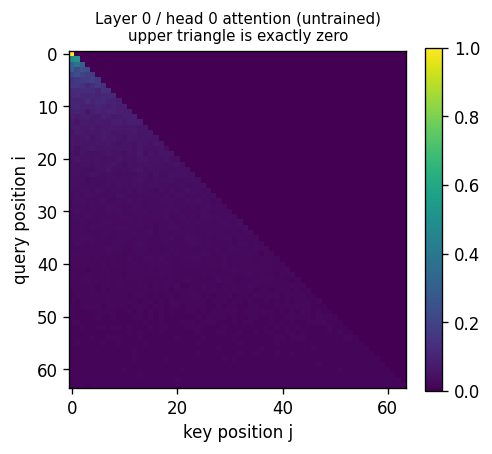

CharGPT(
  (tok_emb): Embedding(78, 256)
  (pos_emb): Embedding(256, 256)
  (drop): Dropout(p=0.05, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (ln1): LayerNorm()
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=False)
        (out_proj): Linear(in_features=256, out_features=256, bias=False)
        (attn_drop): Dropout(p=0.05, inplace=False)
        (resid_drop): Dropout(p=0.05, inplace=False)
      )
      (ln2): LayerNorm()
      (ffn): FeedForward(
        (fc): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (proj): Linear(in_features=1024, out_features=256, bias=True)
        (drop): Dropout(p=0.05, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm()
  (lm_head): Linear(in_features=256, out_features=78, bias=False)
)

In [35]:
# (a) no prebuilt transformer/attention modules anywhere in the model
FORBIDDEN = (
    nn.Transformer, nn.TransformerEncoder, nn.TransformerEncoderLayer,
    nn.TransformerDecoder, nn.TransformerDecoderLayer, nn.MultiheadAttention,
)
offenders = [type(m).__name__ for m in model.modules() if isinstance(m, FORBIDDEN)]
assert not offenders, f"prebuilt modules found: {offenders}"
print("(a) no prebuilt Transformer/attention modules  ->  PASS")
print("    module types used:", sorted({type(m).__name__ for m in model.modules()}))


# (b) behavioural causality test
model.eval()
with torch.no_grad():
    x, _ = get_batch(train_t, torch.tensor([12345]))
    base, _ = model(x)

    j = x.shape[1] * 3 // 4                        # perturb one future position
    x2 = x.clone()
    x2[0, j] = (x2[0, j] + 7) % VOCAB_SIZE
    pert, _ = model(x2)

past_delta   = (base[0, :j]     - pert[0, :j]    ).abs().max().item()
future_delta = (base[0, j:j+5]  - pert[0, j:j+5] ).abs().max().item()
print(f"\n(b) changed token at position {j}")
print(f"    max |Δlogit| at positions <  {j}: {past_delta:.3e}   (must be 0.0)")
print(f"    max |Δlogit| at positions >= {j}: {future_delta:.3e}   (must be > 0)")
assert past_delta == 0.0,  "INFORMATION LEAKED BACKWARDS - causal mask is broken"
assert future_delta > 0.0, "model ignored the perturbation entirely - something else is wrong"
print("    causal masking -> PASS")


# attention pattern picture
with torch.no_grad():
    n_show = min(64, x.shape[1])
    h = model.drop(model.tok_emb(x[:, :n_show]) + model.pos_emb(torch.arange(n_show, device=DEVICE)))
    _, A = model.blocks[0].attn(model.blocks[0].ln1(h), return_attn=True)
amap = A[0, 0].float().cpu().numpy()
assert np.allclose(np.triu(amap, k=1), 0.0), "non-zero attention above the diagonal"

fig, ax = plt.subplots(figsize=(4.2, 4))
im = ax.imshow(amap, cmap="viridis")
ax.set_title("Layer 0 / head 0 attention (untrained)\nupper triangle is exactly zero", fontsize=9)
ax.set_xlabel("key position j"); ax.set_ylabel("query position i")
fig.colorbar(im, fraction=0.046)
fig.tight_layout(); fig.savefig(PLOT_DIR / "causal_mask_check.png"); plt.show()
model.train()


---
## Step 7 — Optimiser, LR warm-up + cosine schedule  *(spec 1.3.1 & 1.3.2)*

**Loss** is cross-entropy over the vocabulary at every one of the `B×T` positions
(spec 1.3.1). In nats per character, it is exactly the quantity that perplexity and
bits-per-character are derived from — so the loss curve *is* the metric curve.

**Optimiser: AdamW**, `betas=(0.9, 0.95)`. The lower β₂ (vs the 0.999 default) shortens the
second-moment memory, which suits the noisy gradients of a short training run.

**Decoupled weight decay, applied selectively.** Only tensors with ≥ 2 dimensions (the weight
matrices) are decayed. LayerNorm gains/biases and bias vectors are 1-D and are left alone —
shrinking a LayerNorm `γ` toward zero would just fight the normalisation it is there to perform.
Embeddings are 2-D and *are* decayed here; that's a defensible choice either way, and a good
thing to have an opinion about in the viva.

**Schedule: linear warm-up → cosine decay.**
* *Warm-up* (first 3% of steps): Adam's variance estimates are garbage on step 1. Hitting a
  freshly initialised model with the full LR is the classic cause of an early loss spike or NaN.
  Ramping from ~0 lets the moment estimates settle first.
* *Cosine decay* to `min_lr`: large steps early to find a good basin, small steps late to settle
  into it. The decay is smooth (unlike step decay) so there is no discontinuity in the loss curve.

**Gradient clipping at global norm 1.0** is the safety net: if a batch produces an unusually
large gradient, it is rescaled rather than allowed to blow the weights apart. The *pre-clip* norm
is what we log as the `gradient norm` stability metric.


2026-09-20 19:40:16 | INFO  | [train] 10 epochs x 1562 steps = 15,620 steps | warmup 781 | batch 64 x 256 tok = 16,384 tok/step
2026-09-20 19:40:16 | INFO  | [train] decayed tensors 51 | undecayed tensors 74


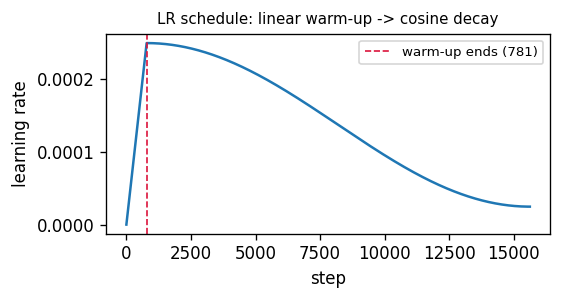

In [36]:
tcfg = CFG["train"]
EPOCHS      = int(tcfg["epochs"])
BATCH_SIZE  = int(tcfg["batch_size"])
GRAD_CLIP   = float(tcfg["grad_clip"])
LOG_EVERY   = int(tcfg["log_every"])
SPIKE_SIGMA = float(tcfg["spike_sigma"])

STEPS_PER_EPOCH = N_TRAIN // BATCH_SIZE
TOTAL_STEPS     = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS    = max(1, int(TOTAL_STEPS * float(tcfg["warmup_ratio"])))
PEAK_LR, MIN_LR = float(tcfg["lr"]), float(tcfg["min_lr"])
VAL_STEPS       = N_VAL // BATCH_SIZE

# --- parameter groups: decay matrices, not norms/biases -------------------------
decay     = [p for p in model.parameters() if p.requires_grad and p.dim() >= 2]
no_decay  = [p for p in model.parameters() if p.requires_grad and p.dim() <  2]
optimizer = torch.optim.AdamW(
    [{"params": decay,    "weight_decay": float(tcfg["weight_decay"])},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=PEAK_LR, betas=tuple(tcfg["betas"]),
)

def lr_at(step: int) -> float:
    """Linear warm-up for WARMUP_STEPS, then cosine decay from PEAK_LR to MIN_LR."""
    if step < WARMUP_STEPS:
        return PEAK_LR * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    return MIN_LR + 0.5 * (PEAK_LR - MIN_LR) * (1 + math.cos(math.pi * progress))

log(f"[train] {EPOCHS} epochs x {STEPS_PER_EPOCH} steps = {TOTAL_STEPS:,} steps "
    f"| warmup {WARMUP_STEPS} | batch {BATCH_SIZE} x {SEQ_LEN} tok = {BATCH_SIZE*SEQ_LEN:,} tok/step")
log(f"[train] decayed tensors {len(decay)} | undecayed tensors {len(no_decay)}")

fig, ax = plt.subplots(figsize=(5, 2.6))
ax.plot([lr_at(s) for s in range(TOTAL_STEPS)])
ax.axvline(WARMUP_STEPS, ls="--", c="crimson", lw=1, label=f"warm-up ends ({WARMUP_STEPS})")
ax.set_xlabel("step"); ax.set_ylabel("learning rate"); ax.legend(fontsize=8)
ax.set_title("LR schedule: linear warm-up -> cosine decay", fontsize=9)
fig.tight_layout(); fig.savefig(PLOT_DIR / "lr_schedule.png"); plt.show()


### Evaluation + resource tracking helpers

`evaluate()` returns, on a held-out split:

* **mean cross-entropy** (nats/char) — averaged over batches, which is an unweighted mean of
  equally sized batches, so it equals the token-level mean.
* **top-1 next-character accuracy** — how often `argmax(logits)` is the true next character.
  Expect ~55–65% for a decent char model: most of the accuracy comes from easy positions (the
  `u` after a `q`, finishing a common word), and the interesting positions are inherently
  uncertain.

`MemTracker` samples device memory because MPS has no `max_memory_allocated`; we poll and keep
the maximum, plus process RSS from `getrusage` as a device-independent floor.


In [37]:
@torch.no_grad()
def evaluate(stream: torch.Tensor, n_sequences: int, max_batches: Optional[int] = None, seed: int = 0):
    """Mean CE loss and top-1 next-char accuracy over a split."""
    was_training = model.training
    model.eval()
    g = torch.Generator().manual_seed(seed)
    starts = epoch_starts(n_sequences, g)
    n_batches = n_sequences // BATCH_SIZE
    if max_batches is not None:
        n_batches = min(n_batches, max_batches)

    tot_loss, tot_correct, tot_tokens = 0.0, 0, 0
    for b in range(n_batches):
        x, y = get_batch(stream, starts[b * BATCH_SIZE:(b + 1) * BATCH_SIZE])
        logits, loss = model(x, y)
        tot_loss    += loss.item()
        tot_correct += (logits.argmax(-1) == y).sum().item()
        tot_tokens  += y.numel()

    if was_training:
        model.train()
    return {"loss": tot_loss / n_batches,
            "top1_acc": tot_correct / tot_tokens,
            "tokens": tot_tokens,
            "batches": n_batches}


class MemTracker:
    """Peak memory, polled (MPS exposes no max-allocated counter)."""
    def __init__(self, device):
        self.device = device
        self.peak_device_mb = 0.0
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()

    def sample(self):
        if self.device.type == "cuda":
            self.peak_device_mb = torch.cuda.max_memory_allocated() / 1e6
        elif self.device.type == "mps":
            self.peak_device_mb = max(self.peak_device_mb,
                                      torch.mps.driver_allocated_memory() / 1e6)
        return self.peak_device_mb

    @staticmethod
    def process_rss_mb():
        ru = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        return ru / 1e6 if sys.platform == "darwin" else ru / 1e3   # macOS bytes, Linux KB


def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elif DEVICE.type == "mps":
        torch.mps.synchronize()


print("helpers ready")


helpers ready


---
## Step 8 — Training loop  *(spec 1.3.3 — minimum 10 epochs)*

One step is: gather batch → forward → cross-entropy → backward → clip → optimiser step,
with the LR set manually from `lr_at(step)` before each step.

Alongside the loss we record the four things the metrics list asks about training stability:

| Recorded | Why it matters |
|---|---|
| pre-clip gradient norm, every step | A healthy run settles into a narrow band. A creeping upward trend means the LR is too high. |
| **loss spikes** — loss above `mean + 3σ` of the last 100 steps | Distinguishes "noisy" from "unstable". A handful is normal; a cluster means trouble. |
| **NaN/Inf count** on loss and grad norm | Any non-zero value invalidates the run; we abort rather than train on garbage. |
| tokens/sec, peak memory | Required hardware-disclosure metrics. |

Validation runs at the end of every epoch over the **full** 10 000-sequence split, and the
best-validation checkpoint is kept separately from the final one. Every line printed here also
lands in the raw log file, untouched.


In [38]:
hist_step  = []   # per-step records
hist_epoch = []   # per-epoch records

mem = MemTracker(DEVICE)
recent_losses = []
spike_count, nan_count = 0, 0
best_val = float("inf")
best_ckpt = CKPT_DIR / f"{RUN_TAG}_best.pt"
last_ckpt = CKPT_DIR / f"{RUN_TAG}_last.pt"

def save_ckpt(path, epoch, val_metrics):
    torch.save({
        "model_state": model.state_dict(),
        "config": CFG,
        "vocab": {"itos": itos, "char_to_idx": char_to_idx, "vocab_size": VOCAB_SIZE},
        "epoch": epoch,
        "val": val_metrics,
        "run_tag": RUN_TAG,
        "params": PARAMS,
    }, path)

log("=" * 92)
log(f"TRAINING START  {RUN_TAG}")
log("=" * 92)

model.train()
g_data = torch.Generator().manual_seed(SEED)
train_t0 = time.time()
global_step = 0
tokens_seen = 0

for epoch in range(1, EPOCHS + 1):
    starts = epoch_starts(N_TRAIN, g_data)          # fresh shuffle each epoch
    epoch_loss, epoch_t0, epoch_tokens = 0.0, time.time(), 0
    window_t0 = time.time()

    for b in range(STEPS_PER_EPOCH):
        lr = lr_at(global_step)
        for grp in optimizer.param_groups:
            grp["lr"] = lr

        x, y = get_batch(train_t, starts[b * BATCH_SIZE:(b + 1) * BATCH_SIZE])
        _, loss = model(x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP).item()
        optimizer.step()

        lv = loss.item()

        # --- stability bookkeeping ------------------------------------------------
        if not math.isfinite(lv) or not math.isfinite(grad_norm):
            nan_count += 1
            log(f"[!!] NaN/Inf at step {global_step}: loss={lv} grad_norm={grad_norm}")
            raise RuntimeError("NaN/Inf encountered - run aborted (see raw log)")
        if len(recent_losses) >= 20:
            mu = float(np.mean(recent_losses)); sd = float(np.std(recent_losses))
            if sd > 0 and lv > mu + SPIKE_SIGMA * sd:
                spike_count += 1
                log(f"[spike] step {global_step}: loss {lv:.4f} > mean {mu:.4f} + {SPIKE_SIGMA}*{sd:.4f}")
        recent_losses.append(lv)
        if len(recent_losses) > 100:
            recent_losses.pop(0)

        epoch_loss   += lv
        epoch_tokens += y.numel()
        tokens_seen  += y.numel()
        global_step  += 1

        hist_step.append({"step": global_step, "epoch": epoch, "lr": lr,
                          "train_loss": lv, "grad_norm": grad_norm})

        if global_step % LOG_EVERY == 0:
            sync()
            dt = time.time() - window_t0
            tps = LOG_EVERY * BATCH_SIZE * SEQ_LEN / dt
            mem.sample()
            log(f"ep {epoch:2d}/{EPOCHS} | step {global_step:6d}/{TOTAL_STEPS} "
                f"| loss {lv:.4f} | ppl {math.exp(min(lv,20)):7.2f} | lr {lr:.2e} "
                f"| gnorm {grad_norm:5.2f} | {tps/1e3:6.1f}k tok/s | mem {mem.peak_device_mb:7.0f}MB")
            window_t0 = time.time()

    # --- end of epoch: full validation pass ---------------------------------------
    sync()
    epoch_time = time.time() - epoch_t0
    train_mean = epoch_loss / STEPS_PER_EPOCH
    val = evaluate(val_t, N_VAL, seed=SEED)
    mem.sample()

    rec = {
        "epoch": epoch,
        "train_loss": train_mean,
        "val_loss": val["loss"],
        "train_ppl": math.exp(min(train_mean, 20)),
        "val_ppl": math.exp(min(val["loss"], 20)),
        "val_bpc": val["loss"] / math.log(2),
        "val_top1_acc": val["top1_acc"],
        "gen_gap": val["loss"] - train_mean,
        "epoch_time_s": epoch_time,
        "tokens_per_sec": epoch_tokens / epoch_time,
        "lr_end": lr,
        "peak_device_mb": mem.peak_device_mb,
    }
    hist_epoch.append(rec)
    log("-" * 92)
    log(f"EPOCH {epoch:2d} | train {train_mean:.4f} | val {val['loss']:.4f} "
        f"| val ppl {rec['val_ppl']:.2f} | bpc {rec['val_bpc']:.4f} "
        f"| top1 {val['top1_acc']*100:.2f}% | gap {rec['gen_gap']:+.4f} "
        f"| {epoch_time/60:.1f} min | {rec['tokens_per_sec']/1e3:.1f}k tok/s")
    log("-" * 92)

    save_ckpt(last_ckpt, epoch, val)
    if val["loss"] < best_val:
        best_val = val["loss"]
        save_ckpt(best_ckpt, epoch, val)
        log(f"[ckpt] new best val {best_val:.4f} -> {best_ckpt.name}")

TOTAL_TRAIN_TIME = time.time() - train_t0
PEAK_DEVICE_MB   = mem.sample()
PEAK_RSS_MB      = MemTracker.process_rss_mb()
TRAIN_TPS        = tokens_seen / TOTAL_TRAIN_TIME

log("=" * 92)
log(f"TRAINING DONE in {TOTAL_TRAIN_TIME/60:.1f} min | {tokens_seen:,} tokens "
    f"| {TRAIN_TPS/1e3:.1f}k tok/s | peak device {PEAK_DEVICE_MB:.0f} MB | peak RSS {PEAK_RSS_MB:.0f} MB")
log(f"stability: {spike_count} loss spikes (>{SPIKE_SIGMA} sigma), {nan_count} NaN/Inf events")
log("=" * 92)

df_step  = pd.DataFrame(hist_step);  df_step.to_csv(OUT_DIR / "train_history_steps.csv", index=False)
df_epoch = pd.DataFrame(hist_epoch); df_epoch.to_csv(OUT_DIR / "train_history_epochs.csv", index=False)
df_epoch


2026-09-20 19:40:17 | INFO  | ============================================================================================
2026-09-20 19:40:17 | INFO  | TRAINING START  task1_shreya_deep_narrow_20260920_194002
2026-09-20 19:40:17 | INFO  | ============================================================================================
2026-09-20 19:40:46 | INFO  | ep  1/10 | step     50/15620 | loss 3.0347 | ppl   20.79 | lr 1.60e-05 | gnorm  1.83 |   28.5k tok/s | mem    8059MB
2026-09-20 19:41:15 | INFO  | ep  1/10 | step    100/15620 | loss 2.7401 | ppl   15.49 | lr 3.20e-05 | gnorm  1.37 |   28.2k tok/s | mem    8059MB
2026-09-20 19:41:44 | INFO  | ep  1/10 | step    150/15620 | loss 2.5808 | ppl   13.21 | lr 4.80e-05 | gnorm  1.02 |   27.8k tok/s | mem    8059MB
2026-09-20 19:42:15 | INFO  | ep  1/10 | step    200/15620 | loss 2.4149 | ppl   11.19 | lr 6.40e-05 | gnorm  1.54 |   26.0k tok/s | mem    8059MB
2026-09-20 19:42:50 | INFO  | ep  1/10 | step    250/15620 | loss 2.3431 | ppl 

,epoch,train_loss,val_loss,train_ppl,val_ppl,val_bpc,val_top1_acc,gen_gap,epoch_time_s,tokens_per_sec,lr_end,peak_device_mb
0,1,1.716975,0.991823,5.567663,2.696145,1.430898,0.691249,-0.725152,1010.572007,25324.081621,0.000248,8058.792448
1,2,0.894737,0.799039,2.446691,2.223403,1.152769,0.749250,-0.095698,1019.430090,25104.034360,0.000236,8058.792448
2,3,0.771782,0.738698,2.163618,2.093208,1.065716,0.767508,-0.033084,1023.785991,24997.224238,0.000214,8058.792448
3,4,0.718719,0.702842,2.051804,2.019483,1.013986,0.777566,-0.015878,1022.381486,25031.564393,0.000183,8058.792448
4,5,0.684725,0.680503,1.983226,1.974871,0.981759,0.784250,-0.004221,1023.329760,25008.368757,0.000147,8058.792448
5,6,0.659643,0.662367,1.934101,1.939378,0.955594,0.789727,0.002725,1025.823472,24947.574995,0.000110,8058.792448
6,7,0.639556,0.650917,1.895640,1.917298,0.939075,0.793394,0.011361,1024.490617,24980.031606,0.000076,8058.792448
7,8,0.623498,0.640672,1.865442,1.897756,0.924294,0.796424,0.017174,1026.377856,24934.099909,0.000049,8058.792448
8,9,0.611484,0.635840,1.843164,1.888609,0.917324,0.798186,0.024357,1022.723766,25023.186947,0.000031,8058.792448
9,10,0.603813,0.632674,1.829080,1.882638,0.912756,0.799055,0.028861,1022.959515,25017.420164,0.000025,8058.792448


---
## Step 8b — Resume point (run this only if you did NOT just train)

Everything below — curves, samples, metrics, failure evidence — depends on state produced by the
training cell (`df_step`, `hist_epoch`, `PEAK_DEVICE_MB`, the trained weights, ...). If your
kernel restarted, or you want to regenerate a report after changing a metric definition, you do
**not** need to retrain: this cell rebuilds that state from what is already on disk.

It reads `outputs/train_history_{steps,epochs}.csv` and the newest `*_best.pt` checkpoint, and
recomputes the stability counters using exactly the same rolling-window rule the training loop
used, so the numbers are identical to the original run.

If you *did* just train, this cell detects that and does nothing.


In [39]:
def _resume_from_disk():
    """Rebuild post-training state from disk. Returns True if a resume happened."""
    global df_step, df_epoch, hist_epoch, model, PARAMS
    global TOTAL_TRAIN_TIME, TRAIN_TPS, PEAK_DEVICE_MB, PEAK_RSS_MB
    global spike_count, nan_count, best_ckpt, last_ckpt, RUN_TAG

    if "df_step" in globals() and "TOTAL_TRAIN_TIME" in globals():
        log("[resume] in-memory training state found - nothing to do")
        return False

    step_csv  = OUT_DIR / "train_history_steps.csv"
    epoch_csv = OUT_DIR / "train_history_epochs.csv"
    ckpts     = sorted(CKPT_DIR.glob("*_best.pt"), key=lambda p: p.stat().st_mtime)
    if not (step_csv.exists() and epoch_csv.exists() and ckpts):
        raise FileNotFoundError(
            "No in-memory state and no saved run to resume from. Run the training cell."
        )

    df_step  = pd.read_csv(step_csv)
    df_epoch = pd.read_csv(epoch_csv)
    hist_epoch = df_epoch.to_dict("records")

    best_ckpt = ckpts[-1]
    last_ckpt = best_ckpt.with_name(best_ckpt.name.replace("_best.pt", "_last.pt"))
    ck = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck["model_state"])
    PARAMS  = ck.get("params", model.num_params())
    RUN_TAG = ck.get("run_tag", RUN_TAG)

    # --- recompute the stability counters with the training loop's exact rule ----
    spike_count, nan_count = 0, 0
    recent = []
    for lv in df_step["train_loss"].tolist():
        if not math.isfinite(lv):
            nan_count += 1
        elif len(recent) >= 20:
            mu, sd = float(np.mean(recent)), float(np.std(recent))
            if sd > 0 and lv > mu + SPIKE_SIGMA * sd:
                spike_count += 1
        recent.append(lv)
        if len(recent) > 100:
            recent.pop(0)

    TOTAL_TRAIN_TIME = float(df_epoch["epoch_time_s"].sum())
    tokens_total     = len(df_step) * BATCH_SIZE * SEQ_LEN
    TRAIN_TPS        = tokens_total / TOTAL_TRAIN_TIME
    PEAK_DEVICE_MB   = float(df_epoch["peak_device_mb"].max())
    PEAK_RSS_MB      = MemTracker.process_rss_mb()

    log(f"[resume] restored {len(df_step):,} steps / {len(df_epoch)} epochs from disk")
    log(f"[resume] checkpoint {best_ckpt.name} (epoch {ck['epoch']}, val {ck['val']['loss']:.4f})")
    log(f"[resume] recomputed: {spike_count} spikes, {nan_count} NaN, "
        f"{TOTAL_TRAIN_TIME/60:.1f} min, {TRAIN_TPS/1e3:.1f}k tok/s, peak {PEAK_DEVICE_MB:.0f} MB")
    log("[resume] NOTE: peak RSS is measured for THIS process, not the training run")
    return True


_resumed = _resume_from_disk()


2026-09-20 22:36:28 | INFO  | [resume] in-memory training state found - nothing to do


---
## Step 9 — Loss curves  *(spec 1.3.4)*

Four panels. What to look for when you write them up:

1. **Train vs val CE.** Both falling and close together = still under-fitting, you could train
   longer or grow the model. Val flattening while train keeps falling = the onset of over-fitting;
   the gap between them *is* the generalization-gap metric.
2. **Step-level train loss** (raw + smoothed) shows the noise floor and any spikes the detector
   flagged.
3. **Validation perplexity** — the same information as CE on an interpretable scale: "the model
   is on average this uncertain between N equally likely characters".
4. **Gradient norm** — the stability trace. Flat band = healthy; the horizontal line is the clip
   threshold, so points above it are steps that actually got clipped.


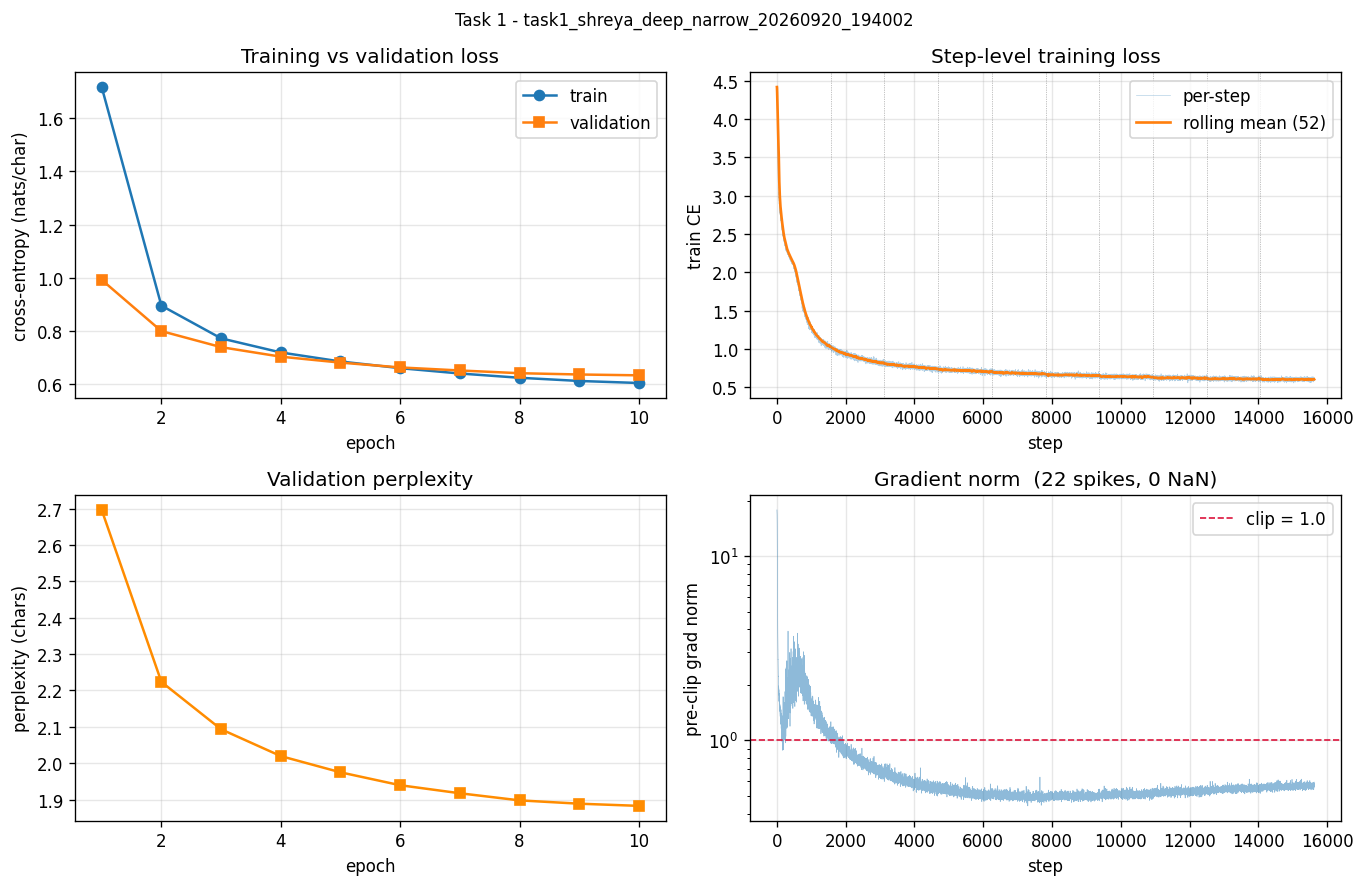

2026-09-20 22:36:31 | INFO  | [plot] saved /content/drive/MyDrive/DATA266_Lab1/task1_llm/shreya/outputs/plots/loss_curves.png


In [40]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.5))

ax = axes[0, 0]
ax.plot(df_epoch.epoch, df_epoch.train_loss, "o-", label="train")
ax.plot(df_epoch.epoch, df_epoch.val_loss,   "s-", label="validation")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy (nats/char)")
ax.set_title("Training vs validation loss"); ax.legend(); ax.grid(alpha=.3)

ax = axes[0, 1]
ax.plot(df_step.step, df_step.train_loss, lw=.4, alpha=.35, label="per-step")
w = max(1, len(df_step) // 300)
ax.plot(df_step.step, df_step.train_loss.rolling(w, min_periods=1).mean(),
        lw=1.6, label=f"rolling mean ({w})")
for e in df_epoch.epoch[:-1]:
    ax.axvline(e * STEPS_PER_EPOCH, color="grey", lw=.4, ls=":")
ax.set_xlabel("step"); ax.set_ylabel("train CE"); ax.set_title("Step-level training loss")
ax.legend(); ax.grid(alpha=.3)

ax = axes[1, 0]
ax.plot(df_epoch.epoch, df_epoch.val_ppl, "s-", color="darkorange")
ax.set_xlabel("epoch"); ax.set_ylabel("perplexity (chars)")
ax.set_title("Validation perplexity"); ax.grid(alpha=.3)

ax = axes[1, 1]
ax.plot(df_step.step, df_step.grad_norm, lw=.4, alpha=.5)
ax.axhline(GRAD_CLIP, color="crimson", ls="--", lw=1, label=f"clip = {GRAD_CLIP}")
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("pre-clip grad norm")
ax.set_title(f"Gradient norm  ({spike_count} spikes, {nan_count} NaN)")
ax.legend(); ax.grid(alpha=.3)

fig.suptitle(f"Task 1 - {RUN_TAG}", fontsize=10)
fig.tight_layout()
fig.savefig(PLOT_DIR / "loss_curves.png", bbox_inches="tight")
plt.show()
log(f"[plot] saved {PLOT_DIR/'loss_curves.png'}")


---
## Step 10 — Text generation  *(spec 1.3.5)*

Autoregressive sampling: feed the prompt, take the logits at the **last** position, choose a
character, append it, repeat. Context is cropped to the last `seq_len` characters because the
learned positional embedding table only has `seq_len` rows.

**Decoding strategies**, both required by the spec:

* **Greedy** — always `argmax`. Deterministic, grammatical, and the classic source of repetition
  loops: once the model enters a state whose most likely continuation returns it to that state,
  it can never escape. Expect to see this in your failure analysis.
* **Temperature sampling** — divide logits by `T`, then sample from the softmax.
  `T < 1` sharpens the distribution (safer, more repetitive); `T > 1` flattens it (more diverse,
  more misspellings and incoherence). `T → 0` is greedy. The temperature sweep at
  `[0.5, 0.8, 1.0, 1.2]` is deliberately wide so the diversity/coherence trade-off is visible in
  your write-up.
* **top-k** (off by default, `top_k: 0`) truncates to the k most likely characters before
  sampling, which removes the long tail of nonsense without sharpening the head.

*Implementation note:* there is no KV cache, so generating `n` tokens costs `n` full forward
passes over the context — O(n·T²). Fine for a few hundred characters; it is the honest reason the
generation tokens/sec figure is far below the training figure.


In [41]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int, temperature: float = 1.0,
             top_k: int = 0, greedy: bool = False, seed: Optional[int] = None) -> str:
    was_training = model.training
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)

    ids = torch.tensor(encode(normalize(prompt)).astype(np.int64),
                       dtype=torch.long, device=DEVICE).unsqueeze(0)

    for _ in range(max_new_tokens):
        ctx = ids[:, -model.max_len:]                     # crop to the positional table
        logits, _ = model(ctx)
        logits = logits[:, -1, :]                         # only the last position predicts next

        if greedy:
            nxt = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / max(temperature, 1e-6)
            if top_k and top_k > 0:
                kth = torch.topk(logits, min(top_k, logits.size(-1)))[0][:, -1:]
                logits = logits.masked_fill(logits < kth, torch.finfo(logits.dtype).min)
            nxt = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)

        ids = torch.cat([ids, nxt], dim=1)

    if was_training:
        model.train()
    return decode(ids[0].tolist())


# reload the best checkpoint so every sample below comes from the reported model
_ck = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
model.load_state_dict(_ck["model_state"])
log(f"[gen] loaded best checkpoint from epoch {_ck['epoch']} (val loss {_ck['val']['loss']:.4f})")

gcfg   = CFG["generation"]
PROMPT = gcfg["prompt"]

# --- generation throughput (required metric) -----------------------------------
sync(); _t0 = time.time()
_ = generate(PROMPT, 500, greedy=True)
sync()
GEN_TPS = 500 / (time.time() - _t0)
log(f"[gen] generation throughput: {GEN_TPS:.1f} tokens/sec (batch=1, no KV cache)")

print("=" * 88); print("GREEDY DECODING"); print("=" * 88)
greedy_sample = generate(PROMPT, int(gcfg["max_new_tokens"]), greedy=True)
print(greedy_sample)


2026-09-20 22:36:31 | INFO  | [gen] loaded best checkpoint from epoch 10 (val loss 0.6327)
2026-09-20 22:36:37 | INFO  | [gen] generation throughput: 87.6 tokens/sec (batch=1, no KV cache)
GREEDY DECODING
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big bird flying in the sky. She was so happy and said, "Hi, I am Lily. Do you want to play with me?"

Lily said, "Yes, please!" Her mom said, "Yes, I can play with you." Lily was happy to hear that her mom was sad. She took her toy and went to the store. She saw that her mom was sad and asked, "What


In [42]:
samples = {"greedy": [greedy_sample]}

for T in gcfg["temperatures"]:
    outs = [generate(PROMPT, int(gcfg["max_new_tokens"]), temperature=float(T),
                     top_k=int(gcfg["top_k"]), seed=SEED + i)
            for i in range(int(gcfg["n_samples_per_setting"]))]
    samples[f"T{T}"] = outs
    print("=" * 88); print(f"TEMPERATURE = {T}"); print("=" * 88)
    print(outs[0][:700]); print()

# persist every sample as evidence
for name, outs in samples.items():
    with open(SAMPLE_DIR / f"{name}.txt", "w", encoding="utf-8") as f:
        for i, s in enumerate(outs):
            f.write(f"===== {name} · sample {i} · prompt={PROMPT!r} =====\n{s}\n\n")
log(f"[gen] wrote {sum(len(v) for v in samples.values())} samples to {SAMPLE_DIR.relative_to(PROJECT_ROOT)}")


TEMPERATURE = 0.5
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park to play on the swings. She saw a big slide and wanted to play with it.

Lily's mom said, "Let's play with it together." They went to the swings and the slide. They saw a big tree with many branches and leaves. Lily said, "Look, Mommy! Look!" Her mom said, "Yes, it is a star. It is a big s

TEMPERATURE = 0.8
Once upon a time, in a big park, there was a little girl named Lily. She loved to play with her toys and go outside to play. One day, her mommy found a map in the garden and asked her what was wrong. Lily told her that it was a little expensive music that she loved the music very much.

"Oh no! I want to be happy but I don't like my music. It's too hot!" Ben said.

Lily smiled and they started to fight over the m

TEMPERATURE = 1.0
Once upon a time, in a big park, there was a little girl named Lily. She loved to play with her toys and go ou

---
## Step 11 — Every required metric → `metrics_report.csv`

Definitions used (state these in your report so the team's numbers are comparable):

| Metric | Definition |
|---|---|
| Train / val CE loss | mean cross-entropy in **nats per character** |
| Perplexity | `exp(CE)` — effective branching factor over characters |
| Bits-per-character | `CE / ln 2` — CE in bits; the standard char-LM figure |
| Generalization gap | `val_CE − train_CE` (final epoch) |
| Top-1 next-char accuracy | fraction of val positions where `argmax(logits)` is correct |
| Distinct-1/2/3 | `unique n-grams / total n-grams` in generated text — reported at **word** level (primary) and **character** level |
| Repeated 4-gram rate | `1 − unique 4-grams / total 4-grams`, i.e. the share of 4-gram occurrences that are repeats |
| Grad norm / stability | mean & max pre-clip global grad norm, spike count, NaN count |
| Parameter count | total / trainable / non-embedding |
| Training tokens/sec | total tokens processed ÷ wall-clock training time |
| Generation tokens/sec | batch-1 greedy decode rate, no KV cache |
| Peak memory | max device allocation + max process RSS |
| Total training time | wall clock for all 10 epochs, validation included |

**Why both word- and char-level distinct-n.** The spec just says "distinct-1/2/3". For a
character model, char-level distinct-1 is `unique characters / total characters`, which is capped
by vocabulary size and therefore near-meaningless (~0.001 for a long sample). Word-level is the
informative version and is what the metric normally means, so we report it as primary and keep
the char-level numbers for completeness. Say which one you are quoting.

Diversity metrics are computed on a single long `T=1.0` sample (`diversity_tokens` characters) so
they are not dominated by the prompt.


In [43]:
def ngrams(seq, n):
    return [tuple(seq[i:i + n]) for i in range(len(seq) - n + 1)]

def distinct_n(seq, n):
    g = ngrams(seq, n)
    return (len(set(g)) / len(g)) if g else float("nan")

def repeated_ngram_rate(seq, n=4):
    g = ngrams(seq, n)
    return (1 - len(set(g)) / len(g)) if g else float("nan")


DIV_TOKENS = int(gcfg["diversity_tokens"])
FIXED_WORDS = int(gcfg.get("diversity_fixed_words", 2000))

log(f"[metrics] generating {DIV_TOKENS:,} chars for diversity stats "
    f"(~{DIV_TOKENS/GEN_TPS/60:.1f} min at {GEN_TPS:.0f} tok/s) ...")
div_text = generate(PROMPT, DIV_TOKENS, temperature=1.0, top_k=int(gcfg["top_k"]), seed=SEED)
(SAMPLE_DIR / "diversity_sample_T1.0.txt").write_text(div_text, encoding="utf-8")

words = div_text.split()
chars = list(div_text)

# distinct-n is sample-size dependent: on a short sample almost every trigram is
# unique, so distinct-3 saturates near 1.0 regardless of model quality. Report the
# full-sample value AND a value at a fixed word count so the number stays
# comparable across members even if diversity_tokens differs.
words_fixed = words[:FIXED_WORDS]
if len(words_fixed) < FIXED_WORDS:
    log(f"[metrics] WARNING: only {len(words_fixed)} words available for the "
        f"fixed-window distinct-n (wanted {FIXED_WORDS}); raise diversity_tokens")

final     = hist_epoch[-1]
best_rec  = min(hist_epoch, key=lambda r: r["val_loss"])
final_val = evaluate(val_t, N_VAL, seed=SEED)          # best checkpoint is loaded
gn        = df_step.grad_norm

# Split stability by training phase. Almost all clipping and loss spikes happen
# during warm-up, when the optimiser's moment estimates are still settling; lumping
# those in with steady state makes a healthy run look unstable.
_post_mask = df_step["step"] > WARMUP_STEPS
gn_post    = gn[_post_mask] if _post_mask.any() else gn
_clipped   = df_step.loc[gn > GRAD_CLIP, "step"]
last_clip_step = int(_clipped.max()) if len(_clipped) else 0

# Recompute which spikes were warm-up vs steady state, using the loop's exact rule.
_spike_steps, _recent = [], []
for _st, _lv in zip(df_step["step"].tolist(), df_step["train_loss"].tolist()):
    if len(_recent) >= 20:
        _mu, _sd = float(np.mean(_recent)), float(np.std(_recent))
        if _sd > 0 and _lv > _mu + SPIKE_SIGMA * _sd:
            _spike_steps.append(_st)
    _recent.append(_lv)
    if len(_recent) > 100:
        _recent.pop(0)
spikes_warmup = sum(1 for st in _spike_steps if st <= WARMUP_STEPS)
spikes_post   = sum(1 for st in _spike_steps if st >  WARMUP_STEPS)

# The final epoch being the best is a signal, not a coincidence: the model was still
# improving when training stopped, so best_ckpt and last_ckpt are the same weights.
if best_rec["epoch"] == EPOCHS:
    log(f"[metrics] NOTE: epoch {EPOCHS} (the last) was also the best -> the model was "
        f"still improving when training stopped. This is an UNDER-FITTING signal, not a "
        f"bug, and it means *_best.pt and *_last.pt hold identical weights. Consider more "
        f"data (data.use_chars), more epochs, or a larger model.")

M = [
    ("train_ce_loss_final_epoch", final["train_loss"],                  "nats/char", "mean over epoch 10"),
    ("val_ce_loss_final_epoch",   final["val_loss"],                    "nats/char", "full val split"),
    ("val_ce_loss_best",          best_rec["val_loss"],                 "nats/char", f"epoch {best_rec['epoch']} (reported checkpoint)"),
    ("val_ce_loss_best_ckpt",     final_val["loss"],                    "nats/char", "re-measured from loaded best checkpoint"),
    ("train_perplexity",          math.exp(min(final['train_loss'],20)),"chars",     "exp(train CE)"),
    ("val_perplexity",            math.exp(min(best_rec['val_loss'],20)),"chars",    "exp(best val CE)"),
    ("bits_per_character",        best_rec["val_loss"] / math.log(2),   "bits/char", "best val CE / ln2"),
    ("generalization_gap",        final["val_loss"] - final["train_loss"], "nats/char", "val - train, final epoch"),
    ("top1_next_char_accuracy",   final_val["top1_acc"],                "fraction",  "argmax == target on full val"),

    ("distinct_1_word",           distinct_n(words, 1),                 "ratio",     f"T=1.0 sample, {len(words)} words"),
    ("distinct_2_word",           distinct_n(words, 2),                 "ratio",     f"word bigrams, {len(words)} words"),
    ("distinct_3_word",           distinct_n(words, 3),                 "ratio",     f"word trigrams, {len(words)} words"),
    ("distinct_1_word_fixed",     distinct_n(words_fixed, 1),           "ratio",     f"first {len(words_fixed)} words (cross-member comparable)"),
    ("distinct_2_word_fixed",     distinct_n(words_fixed, 2),           "ratio",     f"first {len(words_fixed)} words"),
    ("distinct_3_word_fixed",     distinct_n(words_fixed, 3),           "ratio",     f"first {len(words_fixed)} words"),
    ("diversity_sample_words",    len(words),                           "count",     "sample length distinct-n was measured on"),
    ("distinct_1_char",           distinct_n(chars, 1),                 "ratio",     f"{len(chars)} chars"),
    ("distinct_2_char",           distinct_n(chars, 2),                 "ratio",     "char-level bigrams"),
    ("distinct_3_char",           distinct_n(chars, 3),                 "ratio",     "char-level trigrams"),
    ("repeated_4gram_rate_word",  repeated_ngram_rate(words, 4),        "ratio",     "1 - unique/total word 4-grams"),
    ("repeated_4gram_rate_char",  repeated_ngram_rate(chars, 4),        "ratio",     "1 - unique/total char 4-grams"),

    ("grad_norm_mean",            float(gn.mean()),                     "L2",        "pre-clip, all steps"),
    ("grad_norm_median",          float(gn.median()),                   "L2",        "pre-clip"),
    ("grad_norm_max",             float(gn.max()),                      "L2",        "pre-clip, all steps (usually step ~0)"),
    ("grad_clip_hit_rate",        float((gn > GRAD_CLIP).mean()),       "fraction",  f"steps clipped at {GRAD_CLIP}, all steps"),
    # Warm-up transients dominate the all-steps figures and make a stable run look
    # unstable. Split by phase so the steady-state behaviour is visible separately.
    ("grad_norm_max_post_warmup", float(gn_post.max()),                 "L2",        f"pre-clip, steps > {WARMUP_STEPS} (steady state)"),
    ("grad_norm_mean_post_warmup", float(gn_post.mean()),               "L2",        f"pre-clip, steps > {WARMUP_STEPS}"),
    ("grad_clip_hit_rate_post_warmup", float((gn_post > GRAD_CLIP).mean()), "fraction", f"steps > {WARMUP_STEPS}"),
    ("last_clipped_step",         int(last_clip_step),                  "step",      f"final step whose grad norm exceeded {GRAD_CLIP}"),
    ("loss_spike_count",          spike_count,                          "count",     f"loss > mean + {SPIKE_SIGMA}sigma over 100-step window"),
    ("loss_spike_count_warmup",   int(spikes_warmup),                   "count",     f"spikes at step <= {WARMUP_STEPS}"),
    ("loss_spike_count_post_warmup", int(spikes_post),                  "count",     f"spikes after warm-up (the ones that matter)"),
    ("nan_inf_count",             nan_count,                            "count",     "loss or grad norm non-finite"),

    ("param_count_total",         PARAMS["total"],                      "params",    ""),
    ("param_count_trainable",     PARAMS["trainable"],                  "params",    ""),
    ("param_count_non_embedding", PARAMS["non_embedding"],              "params",    "excl. token+position tables"),

    ("train_tokens_per_sec",      TRAIN_TPS,                            "tok/s",     "total tokens / wall clock"),
    ("generation_tokens_per_sec", GEN_TPS,                              "tok/s",     "batch=1 greedy, no KV cache"),
    ("peak_device_memory_mb",     PEAK_DEVICE_MB,                       "MB",        f"{DEVICE.type} allocator"),
    ("peak_process_rss_mb",       PEAK_RSS_MB,                          "MB",        "getrusage maxrss"),
    ("total_training_time_sec",   TOTAL_TRAIN_TIME,                     "s",         f"{EPOCHS} epochs incl. validation"),
    ("total_training_time_min",   TOTAL_TRAIN_TIME / 60,                "min",       ""),

    ("epochs",                    EPOCHS,                               "count",     ""),
    ("vocab_size",                VOCAB_SIZE,                           "count",     "incl. <unk>"),
    ("seq_len",                   SEQ_LEN,                              "tokens",    ""),
    ("batch_size",                BATCH_SIZE,                           "seqs",      ""),
    ("train_sequences",           N_TRAIN,                              "count",     ""),
    ("val_sequences",             N_VAL,                                "count",     ""),
    ("tokens_per_epoch",          N_TRAIN * SEQ_LEN,                    "tokens",    ""),
    ("device",                    HARDWARE["device"],                   "",          HARDWARE.get("cpu_brand", HARDWARE.get("gpu_name", ""))),
]

metrics_df = pd.DataFrame(
    [{"model_id": f"{MEMBER}_{CFG['run']['run_name']}", "run_tag": RUN_TAG,
      "metric": k, "value": v, "unit": u or "", "notes": n or ""} for k, v, u, n in M]
).fillna("")          # empty unit/notes must be "" in the CSV, not the string "nan"
metrics_df.to_csv(METRICS_PATH, index=False)
log(f"[metrics] wrote {METRICS_PATH.relative_to(PROJECT_ROOT)} ({len(metrics_df)} rows)")

pd.set_option("display.max_rows", 200, "display.width", 160)
metrics_df[["metric", "value", "unit", "notes"]]


2026-09-20 22:37:41 | INFO  | [metrics] generating 20,000 chars for diversity stats (~3.8 min at 88 tok/s) ...
2026-09-20 22:42:02 | INFO  | [metrics] NOTE: epoch 10 (the last) was also the best -> the model was still improving when training stopped. This is an UNDER-FITTING signal, not a bug, and it means *_best.pt and *_last.pt hold identical weights. Consider more data (data.use_chars), more epochs, or a larger model.
2026-09-20 22:42:03 | INFO  | [metrics] wrote task1_llm/shreya/metrics_report.csv (50 rows)


,metric,value,unit,notes
0,train_ce_loss_final_epoch,0.603813,nats/char,mean over epoch 10
1,val_ce_loss_final_epoch,0.632674,nats/char,full val split
2,val_ce_loss_best,0.632674,nats/char,epoch 10 (reported checkpoint)
3,val_ce_loss_best_ckpt,0.632674,nats/char,re-measured from loaded best checkpoint
4,train_perplexity,1.82908,chars,exp(train CE)
5,val_perplexity,1.882638,chars,exp(best val CE)
6,bits_per_character,0.912756,bits/char,best val CE / ln2
7,generalization_gap,0.028861,nats/char,"val - train, final epoch"
8,top1_next_char_accuracy,0.799055,fraction,argmax == target on full val
9,distinct_1_word,0.287875,ratio,"T=1.0 sample, 3901 words"


---
## Step 12 — Failure-case evidence  *(spec 1.4 — 2 marks)*

The spec wants **three** failure cases, each with the actual generated snippet plus the failure
type and your observation.

This cell is a *detector*: it generates across the temperature range and automatically surfaces
candidate snippets for the common char-LM failure modes below.

> **Why there are three repetition detectors.** The first version only looked for a phrase
> repeated *immediately* back-to-back, and it reported zero loops on a greedy sample that
> visibly cycles:
> `Her mom said, "Yes, you can see the box in the garage." ... said, "Yes, you can see the box
> too!" Her mom said, "Yes, you can see`
> The repeats are separated by other text, so adjacency-only detection misses them — and
> `repeated_4gram_rate` under-reports them too, because a handful of repeated long phrases barely
> moves a corpus-level ratio. `cyclic_phrase` counts the most frequent word n-gram anywhere in the
> sample, and `top_sentence` counts duplicated clauses. **Read the snippets; do not trust a zero.** It deliberately does **not** write
your analysis — the brief says you must defend this yourself, and `failure_analysis.md` has a
`YOUR OBSERVATION` slot per case for exactly that.

| Detector | Failure type it evidences |
|---|---|
| immediate n-gram loop | **Repetition / degenerate decoding** — a phrase repeated back-to-back |
| **cyclic phrase repetition** | the same failure when the loop has *intervening text* — greedy's real signature |
| **most-repeated sentence** | a whole clause the model keeps returning to |
| non-word rate | **Broken grammar / spelling** — the model emits character strings that aren't words (the price of char-level modelling) |
| entity drift | **Loss of coherence** — a character is introduced and then renamed, or pronouns stop agreeing |
| unterminated / run-on | **No stopping criterion** — the model never produces a story ending |
| confident nonsense | **Hallucination** — fluent, well-formed, factually/narratively impossible |

Pick three, paste the snippet, and write what you actually see.


In [44]:
import re

train_word_set = set(w.strip(".,!?\"'();:").lower() for w in train_text[:5_000_000].split())
train_word_set.discard("")

def longest_immediate_repeat(text, min_len=8, max_len=80):
    """Longest substring that repeats BACK-TO-BACK >= 3 times (adjacent degeneracy)."""
    for L in range(max_len, min_len - 1, -1):
        for i in range(0, len(text) - 3 * L):
            seg = text[i:i + L]
            if not seg.strip():
                continue
            reps = 1
            while text[i + reps * L: i + (reps + 1) * L] == seg:
                reps += 1
            if reps >= 3:
                return {"segment": seg, "reps": reps, "start": i,
                        "snippet": text[max(0, i - 60): i + min(reps, 6) * L + 20]}
    return None


def cyclic_phrase_repeat(text, n=8, min_reps=2):
    """Most frequent word n-gram ANYWHERE in the sample (catches loops with gaps).

    This is the detector that actually finds greedy's failure mode: a phrase the
    model keeps returning to, separated by other text. Adjacency-based detection
    and corpus-level repeated-4-gram ratios both miss it.
    """
    ws = text.split()
    if len(ws) < n + 1:
        return None
    grams = Counter(tuple(ws[i:i + n]) for i in range(len(ws) - n + 1))
    gram, reps = grams.most_common(1)[0]
    if reps < min_reps:
        return None
    phrase = " ".join(gram)
    # show every place it occurs, with a little context
    occurrences, start = [], 0
    while True:
        k = text.find(phrase, start)
        if k == -1 or len(occurrences) >= 4:
            break
        occurrences.append(text[max(0, k - 45): k + len(phrase) + 45])
        start = k + 1
    return {"phrase": phrase, "reps": reps, "n": n, "occurrences": occurrences}


def most_repeated_sentence(text, min_len=20):
    """Most duplicated sentence/clause, split on sentence-final punctuation."""
    parts = [p.strip() for p in re.split(r"(?<=[.!?])\s+", text) if len(p.strip()) >= min_len]
    if not parts:
        return None
    sent, reps = Counter(parts).most_common(1)[0]
    return {"sentence": sent, "reps": reps} if reps >= 2 else None

def non_word_rate(text):
    ws = [w.strip(".,!?\"'();:").lower() for w in text.split()]
    ws = [w for w in ws if w]
    bad = [w for w in ws if w not in train_word_set]
    return (len(bad) / len(ws) if ws else float("nan")), bad[:25]

def entity_drift(text):
    names = re.findall(r"(?<![.!?]\s)(?<!^)\b([A-Z][a-z]{2,})\b", text)
    c = Counter(names)
    return c.most_common(12)

FAIL_SAMPLE_CHARS = 1200

report_lines = []
print("=" * 92)
for tag, T, greedy in [("greedy", None, True), ("T0.5", 0.5, False),
                       ("T0.8", 0.8, False), ("T1.0", 1.0, False), ("T1.2", 1.2, False)]:
    txt = generate(PROMPT, FAIL_SAMPLE_CHARS, temperature=(T or 1.0), greedy=greedy,
                   top_k=int(gcfg["top_k"]), seed=SEED + 99)

    loop   = longest_immediate_repeat(txt)      # back-to-back degeneracy
    cyclic = cyclic_phrase_repeat(txt, n=8)     # loop WITH intervening text
    sent   = most_repeated_sentence(txt)        # duplicated clause
    nwr, bad = non_word_rate(txt)
    ends   = txt.count("\n\n")

    print(f"[{tag:7s}] non-word rate {nwr*100:5.2f}%  | story breaks {ends:2d}")
    print(f"          immediate repeat : "
          f"{str(loop['reps']) + 'x ' + repr(loop['segment'][:40]) if loop else 'none'}")
    print(f"          cyclic phrase    : "
          f"{str(cyclic['reps']) + 'x ' + repr(cyclic['phrase'][:60]) if cyclic else 'none'}")
    print(f"          repeated sentence: "
          f"{str(sent['reps']) + 'x ' + repr(sent['sentence'][:60]) if sent else 'none'}")
    print(f"          odd tokens       : {bad[:10]}")
    print(f"          repeated names   : {entity_drift(txt)[:6]}")

    report_lines.append({
        "setting": tag,
        "non_word_rate": nwr,
        "story_breaks": ends,
        "immediate_reps": loop["reps"] if loop else 0,
        "immediate_segment": loop["segment"] if loop else "",
        "cyclic_reps": cyclic["reps"] if cyclic else 0,
        "cyclic_phrase": cyclic["phrase"] if cyclic else "",
        "sentence_reps": sent["reps"] if sent else 0,
        "repeated_sentence": sent["sentence"] if sent else "",
        "odd_tokens": ", ".join(bad[:15]),
        "_loop_snippet": loop["snippet"] if loop else "",
        "_cyclic_occurrences": cyclic["occurrences"] if cyclic else [],
        "text": txt,
    })
    print("-" * 92)

fail_df = pd.DataFrame(report_lines)
_csv_cols = [c for c in fail_df.columns if c != "text" and not c.startswith("_")]
fail_df[_csv_cols].to_csv(OUT_DIR / "failure_detectors.csv", index=False)

with open(OUT_DIR / "failure_candidates.md", "w", encoding="utf-8") as f:
    f.write(f"# Failure-case candidates - {RUN_TAG}\n\n")
    f.write("Auto-generated evidence. Choose three, move them into ../failure_analysis.md,\n")
    f.write("and write the observation in your own words.\n\n")
    f.write("Detectors: `immediate` = phrase repeated back-to-back; `cyclic` = most frequent\n")
    f.write("8-word phrase anywhere in the sample (catches loops with intervening text);\n")
    f.write("`sentence` = most duplicated clause. A zero from one detector does not mean the\n")
    f.write("sample is clean - read the text.\n\n")
    for r in report_lines:
        f.write(f"\n## Setting: {r['setting']}\n\n")
        f.write(f"- non-word rate: **{r['non_word_rate']*100:.2f}%**\n")
        f.write(f"- story breaks (blank lines): {r['story_breaks']}\n")
        f.write(f"- immediate repeat: {r['immediate_reps']}x {r['immediate_segment']!r}\n")
        f.write(f"- cyclic phrase: **{r['cyclic_reps']}x** {r['cyclic_phrase']!r}\n")
        f.write(f"- repeated sentence: {r['sentence_reps']}x {r['repeated_sentence']!r}\n")
        f.write(f"- odd tokens: {r['odd_tokens']}\n\n")
        if r["_loop_snippet"]:
            f.write("### Immediate-repetition snippet\n\n```\n" + r["_loop_snippet"] + "\n```\n\n")
        if r["_cyclic_occurrences"]:
            f.write(f"### Cyclic repetition - each occurrence of {r['cyclic_phrase']!r}\n\n")
            for k, occ in enumerate(r["_cyclic_occurrences"], 1):
                f.write(f"{k}. `...{occ}...`\n")
            f.write("\n")
        f.write(f"### Full {FAIL_SAMPLE_CHARS}-char sample\n\n```\n" + r["text"] + "\n```\n")

log(f"[failure] evidence -> {(OUT_DIR/'failure_candidates.md').relative_to(PROJECT_ROOT)}")
fail_df[_csv_cols]


[greedy ] non-word rate  0.00%  | story breaks  5
          immediate repeat : none
          cyclic phrase    : 2x 'Once upon a time, there was a little'
          repeated sentence: 2x 'Once upon a time, there was a little girl named Lily.'
          odd tokens       : []
          repeated names   : [('Lily', 13), ('Her', 5), ('Yes', 2), ('What', 1), ('Once', 1), ('Look', 1)]
--------------------------------------------------------------------------------------------
[T0.5   ] non-word rate  0.00%  | story breaks  4
          immediate repeat : none
          cyclic phrase    : 2x 'Once upon a time, there was a little'
          repeated sentence: 2x 'Once upon a time, there was a little girl named Lily.'
          odd tokens       : []
          repeated names   : [('Lily', 7), ('Thank', 1), ('Mommy', 1), ('Her', 1), ('Once', 1), ('The', 1)]
--------------------------------------------------------------------------------------------
[T0.8   ] non-word rate  0.42%  | story breaks  5

,setting,non_word_rate,story_breaks,immediate_reps,immediate_segment,cyclic_reps,cyclic_phrase,sentence_reps,repeated_sentence,odd_tokens
0,greedy,0.000000,5,0,,2,"Once upon a time, there was a little",2,"Once upon a time, there was a little girl name...",
1,T0.5,0.000000,4,0,,2,"Once upon a time, there was a little",2,"Once upon a time, there was a little girl name...",
2,T0.8,0.004219,5,0,,0,,0,,spec
3,T1.0,0.012876,5,0,,0,,0,,"strets, shaked, en"
4,T1.2,0.030435,6,0,,0,,0,,"too.s, pasty, knowled, pumpins, a-, pancaking, p"


---
## Step 13 — Reproducibility manifest  *(spec section 5)*

The brief requires "package/library versions, environment file, and which checkpoint maps to
which result". This writes all of it to `reproducibility/manifests/`, including a SHA-256 of the
reported checkpoint so the mapping from *number in the report* → *file on disk* is verifiable.

Also written: `requirements.txt` (exact pinned versions from this interpreter).


In [45]:
def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for blk in iter(lambda: f.read(chunk), b""):
            h.update(blk)
    return h.hexdigest()

try:
    freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True).splitlines()
except Exception as e:
    freeze = [f"<pip freeze failed: {e}>"]

# Checkpoint paths are resolved here, not inherited from the training cell, so this
# cell can be run on its own after a restart. Replace with a literal filename to pin
# a specific run.
BEST_CKPT = sorted(CKPT_DIR.glob("*_best.pt"))[-1]
LAST_CKPT = BEST_CKPT.with_name(BEST_CKPT.name.replace("_best.pt", "_last.pt"))
_meta = torch.load(BEST_CKPT, map_location="cpu", weights_only=False)

# RUN_TAG is regenerated with a new timestamp every session. Take the training run's
# tag from the checkpoint instead, so the manifest, the log and the weights all agree.
CKPT_RUN_TAG = _meta.get("run_tag", RUN_TAG)
print(f"manifest for {CKPT_RUN_TAG}\n  best: {BEST_CKPT.name}\n  last: {LAST_CKPT.name}")

manifest = {
    "run_tag": CKPT_RUN_TAG,
    "task": "task1_llm",
    "member": MEMBER,
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "seed": SEED,
    "config": CFG,
    "hardware": HARDWARE,
    "data": {
        "raw_pool_file": str(RAW_TXT),   # absolute: LAB1_DATA can put it outside the repo
        "raw_pool_sha256": sha256(RAW_TXT),
        "raw_pool_chars": file_chars,
        "slice_offset_chars": OFFSET,
        "slice_chars": len(raw_text),
        "n_stories": len(stories),
        "train_stories": len(train_stories), "val_stories": len(val_stories),
        "vocab_size": VOCAB_SIZE,
        "train_tokens": int(len(train_ids)), "val_tokens": int(len(val_ids)),
        "train_unk_rate": train_unk, "val_unk_rate": val_unk,
    },
    "artifacts": {
        "best_checkpoint": str(BEST_CKPT.relative_to(PROJECT_ROOT)),
        "best_checkpoint_sha256": sha256(BEST_CKPT),
        "best_checkpoint_epoch": int(_meta["epoch"]),
        "last_checkpoint": str(LAST_CKPT.relative_to(PROJECT_ROOT)),
        "raw_log": f"reproducibility/raw_logs/{MEMBER}/task1_llm/{CKPT_RUN_TAG}.log",
        "metrics_report": str(METRICS_PATH.relative_to(PROJECT_ROOT)),
        "loss_curves": str((PLOT_DIR / "loss_curves.png").relative_to(PROJECT_ROOT)),
        "samples_dir": str(SAMPLE_DIR.relative_to(PROJECT_ROOT)),
    },
    "headline_metrics": {
        "val_ce_loss": best_rec["val_loss"],
        "val_perplexity": math.exp(min(best_rec["val_loss"], 20)),
        "bits_per_character": best_rec["val_loss"] / math.log(2),
        "top1_next_char_accuracy": final_val["top1_acc"],
        "generalization_gap": final["val_loss"] - final["train_loss"],
        "param_count": PARAMS["total"],
        "total_training_time_min": TOTAL_TRAIN_TIME / 60,
    },
    "pip_freeze": freeze,
}

mpath = MANIFEST_DIR / f"{CKPT_RUN_TAG}.json"
mpath.write_text(json.dumps(manifest, indent=2))
REQS_PATH.write_text("\n".join(freeze) + "\n")

log(f"[manifest] {mpath.relative_to(PROJECT_ROOT)}")
log(f"[manifest] checkpoint sha256 {manifest['artifacts']['best_checkpoint_sha256'][:16]}...")
print(json.dumps(manifest["headline_metrics"], indent=2))

manifest for task1_shreya_deep_narrow_20260920_194002
  best: task1_shreya_deep_narrow_20260920_194002_best.pt
  last: task1_shreya_deep_narrow_20260920_194002_last.pt
2026-09-20 22:43:16 | INFO  | [manifest] reproducibility/manifests/task1_shreya_deep_narrow_20260920_194002.json
2026-09-20 22:43:16 | INFO  | [manifest] checkpoint sha256 f540786b227da1a6...
{
  "val_ce_loss": 0.6326739027714118,
  "val_perplexity": 1.8826378456112687,
  "bits_per_character": 0.912755502028182,
  "top1_next_char_accuracy": 0.7990546593299279,
  "generalization_gap": 0.028860723409423694,
  "param_count": 9570816,
  "total_training_time_min": 176.18874078591665
}


---
## Done — what to do next

Artifacts this run produced:

```
task1_llm/shreya/
├── metrics_report.csv              ← every required metric
├── requirements.txt
├── checkpoints/*_best.pt, *_last.pt
├── data_processed/{vocab.json, train_ids.npy, val_ids.npy}
└── outputs/
    ├── train_history_{steps,epochs}.csv
    ├── failure_detectors.csv, failure_candidates.md
    ├── plots/{loss_curves, lr_schedule, causal_mask_check}.png
    └── samples/*.txt
reproducibility/
├── raw_logs/<RUN_TAG>.log          ← DO NOT EDIT
└── manifests/<RUN_TAG>.json
```

**Still to write, in your own words** (the brief says these must be yours):

1. `../failure_analysis.md` — pick 3 cases from `outputs/failure_candidates.md`, paste the
   snippet, name the failure type, write what you observe and why you think it happens.
2. `../results.md` — architecture + hyperparameter justification, the metrics table, what the
   curves show, and what you'd change next.

Before the viva, be able to answer: why pre-norm, why `1/√d_k`, why the vocab is built from train
only, why warm-up, why top-1 accuracy is ~60% and not higher, and what distinct-n at word level
means versus character level.
